# **Import Utilities**

In [1]:
# import pyarrow as pa
# import pyarrow.parquet as pq
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd

import sys
sys.path.append('../')  # Add the parent directory where 'utils' is to the Python path
from utils.llm_evaluation_utils import EVALUATION_MAIN_ASPECTS, EVALUATION_FIVE_ASPECTS
from utils.data_setup import load_existing_responses
from utils.statistics_plots_analysis_utils import *

TASK_SUBSET = "1000"           # "all" | "1000" | "50"
PROMPTING_TYPE = "zero_shot"    # "zero_shot" | "few_shot"
STAGE = "ratings"              # "ratings" or "critiques"
NUM_TRIALS = 1

CATEGORIES_DICT = {
        'aesthetics_rating': list(range(1, 11)),
        'learnability': list(range(1, 6)),
        'efficiency': list(range(1, 6)),
        'usability_rating': list(range(1, 11)),
        'design_quality_rating': list(range(1, 11))
    }

MODEL_SHORT = {
    'GPT-5': 'gpt5',
    'Gemini-2.5': 'gemini2_5pro',
    'Claude-4': 'claude4',
    'Qwen-3': 'qwen3_vl',
}

MODEL_COLORS = {
    "Expert": "#9E9E9E",
    "Claude-4": "#F89838",
    "GPT-5": "#5288C1",
    "Gemini-2.5": "#73C068",
    "Qwen-3": "#AF4EC5",
}

ASPECTS_10 = ['aesthetics_rating', 'usability_rating', 'design_quality_rating']
ASPECTS_5  = ['learnability', 'efficiency']

In [ ]:
SELECTED_TASKS = f"{TASK_SUBSET}_screens" if TASK_SUBSET != "all" else "all_tasks"

dataset_dir = Path("../../data/dataset/cleaned_dataset")
uicrit_data_file = dataset_dir / "uicrit_notna_deduped.parquet"
base64_screens_file = Path(dataset_dir) / "base64_screens.parquet"

results_dir = Path(f"../results/{STAGE}/parquet")

results_file_base = f"{STAGE}-{{prompting_type}}-{SELECTED_TASKS}-{{model_short}}-responses.parquet"

selected_models = [
    "GPT-5", 
    # "Gemini-2.5", 
    # "Claude-4", 
    # "Qwen-3"
    ]


# **Load Data**

Load Experts Data

In [7]:
# load experts data
experts_df = pd.read_parquet(uicrit_data_file, columns=['screen_task_id', 'screen_id', *EVALUATION_FIVE_ASPECTS])

print('experts_df shape:', experts_df.shape)
experts_df.head(1)

experts_df shape: (2957, 7)


,screen_task_id,screen_id,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating
0,15_T01,15,6,3,3,6,6


**Load and Merge Model Responses to Experts**

In [11]:
def load_and_merge_models(prompting_type, selected_models, results_file_base):
    model_results_files = {
        model: results_dir / results_file_base.format(model_short=MODEL_SHORT[model], prompting_type=prompting_type)
        for model in selected_models
    }

    model_dfs = {}

    for model_name, path in model_results_files.items():
        df = load_existing_responses(
            results_file_path=path,
            uicrit_file=uicrit_data_file,
            num_trials=NUM_TRIALS,
            stage=STAGE,
        )

        df = df.rename(
            columns={m: f"{m}_llm" for m in EVALUATION_FIVE_ASPECTS}
        )

        merged_df = pd.merge(df, experts_df, on=["screen_task_id", "screen_id"])
        model_dfs[model_name] = merged_df

        print(f"{prompting_type} | {model_name} shape: {merged_df.shape} | N/A count:", merged_df.isna().sum().sum())

    return model_dfs

model_dfs_zs = load_and_merge_models("zero_shot", selected_models, results_file_base)
model_dfs_fs = load_and_merge_models("few_shot", selected_models, results_file_base)

zero_shot | GPT-5 shape: (1000, 13) | N/A count: 0
zero_shot | Gemini-2.5 shape: (1000, 13) | N/A count: 0
zero_shot | Claude-4 shape: (1000, 13) | N/A count: 0
zero_shot | Qwen-3 shape: (1000, 13) | N/A count: 5
few_shot | GPT-5 shape: (997, 13) | N/A count: 0
few_shot | Gemini-2.5 shape: (997, 13) | N/A count: 0
few_shot | Claude-4 shape: (997, 13) | N/A count: 0
few_shot | Qwen-3 shape: (997, 13) | N/A count: 5


In [6]:
# keep in experts_df rows that are in any model_dfs_zs
experts_df_filtered = experts_df[
    experts_df.apply(
        lambda row: any(
            row['screen_task_id'] in model_dfs_zs[model]['screen_task_id'].values and
            row['screen_id'] in model_dfs_zs[model]['screen_id'].values
            for model in model_dfs_zs
        ),
        axis=1
    )
]
print('experts_df_filtered shape:', experts_df_filtered.shape)
experts_df_filtered.head(1)

experts_df_filtered shape: (1000, 7)


,screen_task_id,screen_id,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating
0,15_T01,15,6,3,3,6,6


Make it ONE dataframe

In [7]:
def to_long_df(model_dfs, prompting_type):
    rows = []

    for model, df in model_dfs.items():
        for aspect in EVALUATION_FIVE_ASPECTS:
            tmp = df[[
                'screen_task_id', 'screen_id',
                aspect, f'{aspect}_llm'
            ]].copy()

            tmp['model'] = model
            tmp['prompting'] = prompting_type
            tmp['aspect'] = aspect
            tmp['expert_score'] = tmp[aspect]
            tmp['llm_score'] = tmp[f'{aspect}_llm']
            tmp['delta'] = tmp['llm_score'] - tmp['expert_score']

            rows.append(
                tmp[['screen_task_id','screen_id','model','prompting',
                     'aspect','expert_score','llm_score','delta']]
            )

    return pd.concat(rows, ignore_index=True)

In [8]:
long_zs = to_long_df(model_dfs_zs, "zero_shot")
long_fs = to_long_df(model_dfs_fs, "few_shot")

ratings_long = pd.concat([long_zs, long_fs], ignore_index=True)
ratings_long.head(2)

,screen_task_id,screen_id,model,prompting,aspect,expert_score,llm_score,delta
0,15_T01,15,GPT-5,zero_shot,aesthetics_rating,6,7.0,1.0
1,28_T01,28,GPT-5,zero_shot,aesthetics_rating,6,6.0,0.0


Sanity checks

In [34]:
ratings_long.groupby(['model','aspect'])[['expert_score','llm_score']].describe()

expert_score                                \
                                        count      mean       std  min  25%   
model      aspect                                                             
Claude-4   aesthetics_rating           1997.0  5.796695  1.068650  3.0  5.0   
           design_quality_rating       1997.0  5.874812  1.007662  3.0  5.0   
           efficiency                  1997.0  3.012519  0.656663  2.0  3.0   
           learnability                1997.0  2.974462  0.613679  2.0  3.0   
           usability_rating            1997.0  5.841763  1.068308  4.0  5.0   
GPT-5      aesthetics_rating           1997.0  5.796695  1.068650  3.0  5.0   
           design_quality_rating       1997.0  5.874812  1.007662  3.0  5.0   
           efficiency                  1997.0  3.012519  0.656663  2.0  3.0   
           learnability                1997.0  2.974462  0.613679  2.0  3.0   
           usability_rating            1997.0  5.841763  1.068308  4.0  5.0   
Gemini-2.5 aesthetics_rating           1997.0  5.796695  1.068650  3.0  5.0   
           design_quality_rating       1997.0  5.874812  1.007662  3.0  5.0   
           efficiency                  1997.0  3.012519  0.656663  2.0  3.0   
           learnability                1997.0  2.974462  0.613679  2.0  3.0   
           usability_rating            1997.0  5.841763  1.068308  4.0  5.0   
Qwen-3     aesthetics_rating           1997.0  5.796695  1.068650  3.0  5.0   
           design_quality_rating       1997.0  5.874812  1.007662  3.0  5.0   
           efficiency                  1997.0  3.012519  0.656663  2.0  3.0   
           learnability                1997.0  2.974462  0.613679  2.0  3.0   
           usability_rating            1997.0  5.841763  1.068308  4.0  5.0   

                                                 llm_score            \
                                  50%  75%   max     count      mean   
model      aspect                                                      
Claude-4   aesthetics_rating      6.0  6.0   9.0    1997.0  6.409614   
           design_quality_rating  6.0  6.0   9.0    1997.0  6.571357   
           efficiency             3.0  3.0   5.0    1997.0  4.114171   
           learnability           3.0  3.0   5.0    1997.0  4.228843   
           usability_rating       6.0  7.0  10.0    1997.0  8.097646   
GPT-5      aesthetics_rating      6.0  6.0   9.0    1997.0  5.842764   
           design_quality_rating  6.0  6.0   9.0    1997.0  5.988483   
           efficiency             3.0  3.0   5.0    1997.0  3.786179   
           learnability           3.0  3.0   5.0    1997.0  4.090636   
           usability_rating       6.0  7.0  10.0    1997.0  7.335503   
Gemini-2.5 aesthetics_rating      6.0  6.0   9.0    1997.0  4.822233   
           design_quality_rating  6.0  6.0   9.0    1997.0  5.061592   
           efficiency             3.0  3.0   5.0    1997.0  4.208312   
           learnability           3.0  3.0   5.0    1997.0  4.459189   
           usability_rating       6.0  7.0  10.0    1997.0  7.984477   
Qwen-3     aesthetics_rating      6.0  6.0   9.0    1995.0  6.297744   
           design_quality_rating  6.0  6.0   9.0    1995.0  6.282707   
           efficiency             3.0  3.0   5.0    1995.0  4.130827   
           learnability           3.0  3.0   5.0    1995.0  4.452632   
           usability_rating       6.0  7.0  10.0    1995.0  8.200501   

                                                                       
                                       std  min  25%  50%   75%   max  
model      aspect                                                      
Claude-4   aesthetics_rating      1.092178  2.0  6.0  7.0   7.0   9.0  
           design_quality_rating  1.101802  2.0  6.0  7.0   7.0   8.0  
           efficiency             0.839878  1.0  4.0  4.0   5.0   5.0  
           learnability           0.713602  1.0  4.0  4.0   5.0   5.0  
           usability_rating       1.524345  1.0  8.0  

In [ ]:
import string

def _plot_hist(ax, vals, max_val, title):
    """
    ax: matplotlib axis
    vals: array of integer ratings
    max_val: 10 or 5
    title: subplot title
    """
    # Ensure all bins from 1 to max_val exist
    counts = np.bincount(vals, minlength=max_val+1)[1:]  # skip 0 index
    x = np.arange(1, max_val+1)

    ax.bar(x, counts, edgecolor='black', color='#1f77b4', alpha=0.9)

    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xlim(0.5, max_val + 0.5)
    ax.set_ylim(0, max(max(counts), 1) * 1.1)
    ax.set_ylabel("Count")
    # remove grid
    ax.grid(False)

    # Show counts on top of bars (including zeros)
    for xi, c in zip(x, counts):
        ax.text(xi, c, int(c), ha='center', va='bottom', fontsize=9)

def plot_expert_histograms(experts_df_filtered):
    fig, axes = plt.subplots(2, 3, figsize=(14, 7))
    axes = axes.flatten()

    # Create subplot labels a-e
    subplot_labels = list(string.ascii_lowercase[:5])

        # out of 10
    for i, aspect in enumerate(ASPECTS_10):
        vals = experts_df_filtered[aspect].dropna().astype(int)
        _plot_hist(
            ax=axes[i],
            vals=vals,
            max_val=10,
            title=f"({subplot_labels[i]}) {aspect.replace('rating', '').replace('_', ' ').title()}"
        )

    # out of 5
    for j, aspect in enumerate(ASPECTS_5):
        idx = 3 + j
        vals = experts_df_filtered[aspect].dropna().astype(int)
        _plot_hist(
            ax=axes[idx],
            vals=vals,
            max_val=5,
            title=f"({subplot_labels[idx]}) {aspect.replace('rating', '').replace('_', ' ').title()}"
        )

    # remove empty subplot (bottom-right)
    fig.delaxes(axes[-1])

    plt.suptitle("Expert Rating Distributions", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

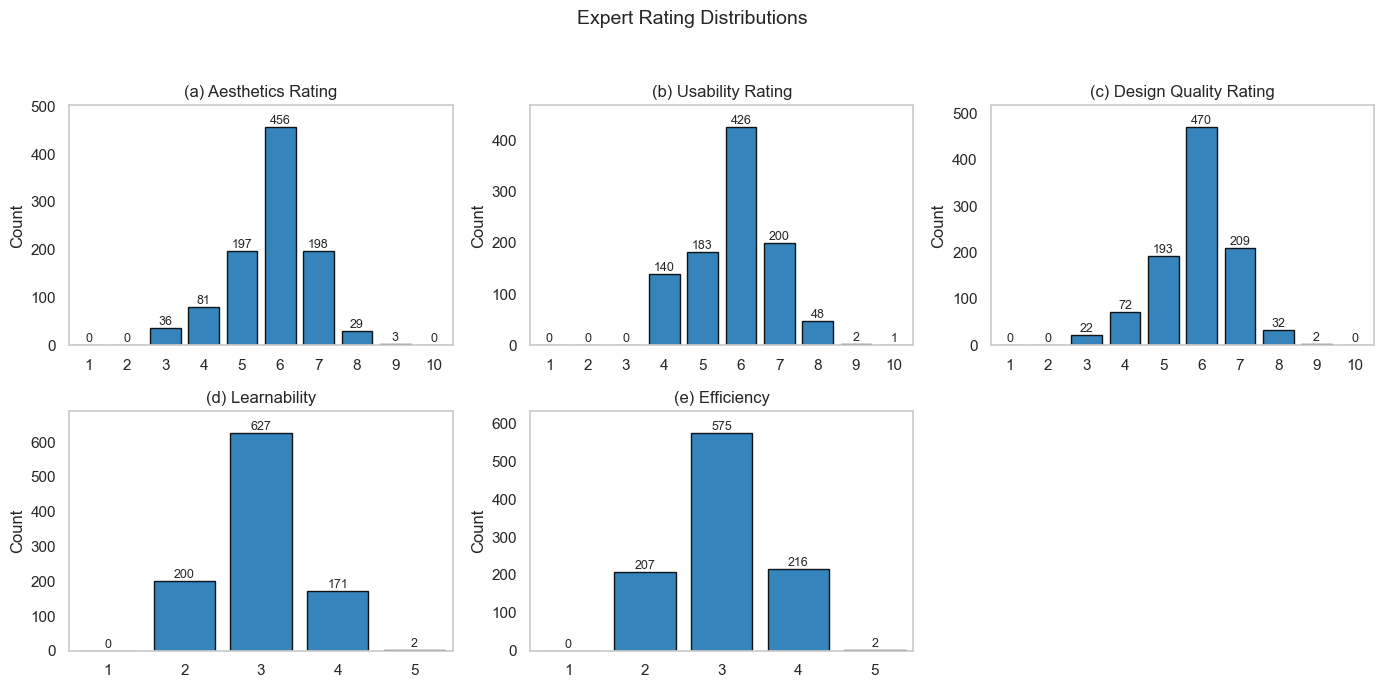

In [387]:
plot_expert_histograms(experts_df_filtered)

Box Plots

In [474]:
def plot_clean_boxplots(plot_zs, plot_fs, model_order, aspects_10, aspects_5, MODEL_COLORS):
    bar_width = 0.35  # width per prompting
    gap_between_models = 0.5

    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    for i, (ax, aspects, ylim, ylabel) in enumerate(zip(
            axes, [aspects_10, aspects_5], [(0,10.5),(0,5.5)], ["Ratings (out of 10)", "Ratings (out of 5)"]
        )):
        subplot_labels = ['(a)', '(b)']
        # positions
        metric_centers = []
        x_positions = {}  # (model/prompting, aspect) -> x

        cursor = 0
        for aspect in aspects:
            for model in model_order:
                if model == "Expert":
                    x_positions[(model, aspect)] = cursor + bar_width/2  # single box
                else:
                    x_positions[(model,"zero_shot", aspect)] = cursor
                    x_positions[(model,"few_shot", aspect)] = cursor + bar_width
                cursor += 2*bar_width + gap_between_models
            metric_centers.append(cursor - (2*bar_width + gap_between_models)/2)

        # Plot Expert boxes
        expert_df_zs = plot_zs[plot_zs['model']=="Expert"]
        for aspect in aspects:
            vals = expert_df_zs[expert_df_zs['aspect']==aspect]['score'].values
            ax.boxplot(vals, positions=[x_positions[("Expert", aspect)]],
                       widths=bar_width, patch_artist=True,
                       boxprops=dict(facecolor='grey', alpha=0.7),
                       medianprops=dict(color='black'))

        # Plot models
        for model in model_order:
            if model=="Expert": continue
            # Zero-shot
            df = plot_zs[plot_zs['model']==model]
            for aspect in aspects:
                vals = df[df['aspect']==aspect]['score'].values
                ax.boxplot(vals, positions=[x_positions[(model,"zero_shot", aspect)]],
                           widths=bar_width, patch_artist=True,
                           boxprops=dict(facecolor=MODEL_COLORS[model], alpha=0.5),
                           medianprops=dict(color='black'))
            # Few-shot
            df = plot_fs[plot_fs['model']==model]
            for aspect in aspects:
                vals = df[df['aspect']==aspect]['score'].values
                ax.boxplot(vals, positions=[x_positions[(model,"few_shot", aspect)]],
                           widths=bar_width, patch_artist=True,
                           boxprops=dict(facecolor=MODEL_COLORS[model], alpha=0.9),
                           medianprops=dict(color='black'))

            # # Connect medians
            # for aspect in aspects:
            #     zs_x = x_positions[(model,"zero_shot", aspect)]
            #     fs_x = x_positions[(model,"few_shot", aspect)]
            #     zs_y = plot_zs[(plot_zs['model']==model) & (plot_zs['aspect']==aspect)]['score'].median()
            #     fs_y = plot_fs[(plot_fs['model']==model) & (plot_fs['aspect']==aspect)]['score'].median()
            #     ax.plot([zs_x, fs_x], [zs_y, fs_y], color=MODEL_COLORS[model], alpha=0.7, linewidth=1)

        # Remove default ticks
        ax.set_xticks([])
        for aspect in aspects[:-1]:  # skip last aspect
            # rightmost box of this aspect (Expert + ZS + FS)
            all_positions = []
            for model in model_order:
                if model == "Expert":
                    all_positions.append(x_positions[(model, aspect)])
                else:
                    all_positions.append(x_positions[(model,"zero_shot", aspect)])
                    all_positions.append(x_positions[(model,"few_shot", aspect)])
            right_edge = max(all_positions) + bar_width/2 + 0.35  # slightly past last box
            ax.axvline(right_edge, color='grey', linestyle='--', alpha=0.5)

        # Manually add aspect labels centered under each block (without moving the border)
        for aspect in aspects:
            # get all box positions for this aspect (Expert + ZS + FS)
            all_positions = []
            for model in model_order:
                if model == "Expert":
                    all_positions.append(x_positions[(model, aspect)])
                else:
                    all_positions.append(x_positions[(model,"zero_shot", aspect)])
                    all_positions.append(x_positions[(model,"few_shot", aspect)])
            center_x = np.mean(all_positions)
            
            ax.text(center_x, ylim[0]-0.05*(ylim[1]-ylim[0]), 
                    aspect.replace("_"," ").title(),
                    ha='center', va='top', fontsize=11)


        # Subplot labels
        ax.text(-0.05, 1.02, subplot_labels[i], transform=ax.transAxes, fontsize=14, fontweight='bold', va='top', ha='right')
        ax.set_ylabel(ylabel, fontsize=12)
        ax.set_ylim(ylim)
        ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Shared legend at bottom
    handles = [plt.Line2D([0],[0], color=MODEL_COLORS[m], lw=6) for m in model_order if m!="Expert"]
    labels = [m for m in model_order if m!="Expert"]
    handles.append(plt.Line2D([0],[0], color='grey', lw=6))
    labels.append("Expert")
    fig.legend(handles, labels, loc='lower center', ncol=len(labels), frameon=False, title="Models")

    fig.suptitle("Box Plot for Model Ratings: Zero-Shot vs Few-Shots", fontsize=16, weight='bold')
    plt.tight_layout(rect=[0,0.05,1,1])  # leave space at bottom for legend
    plt.show()


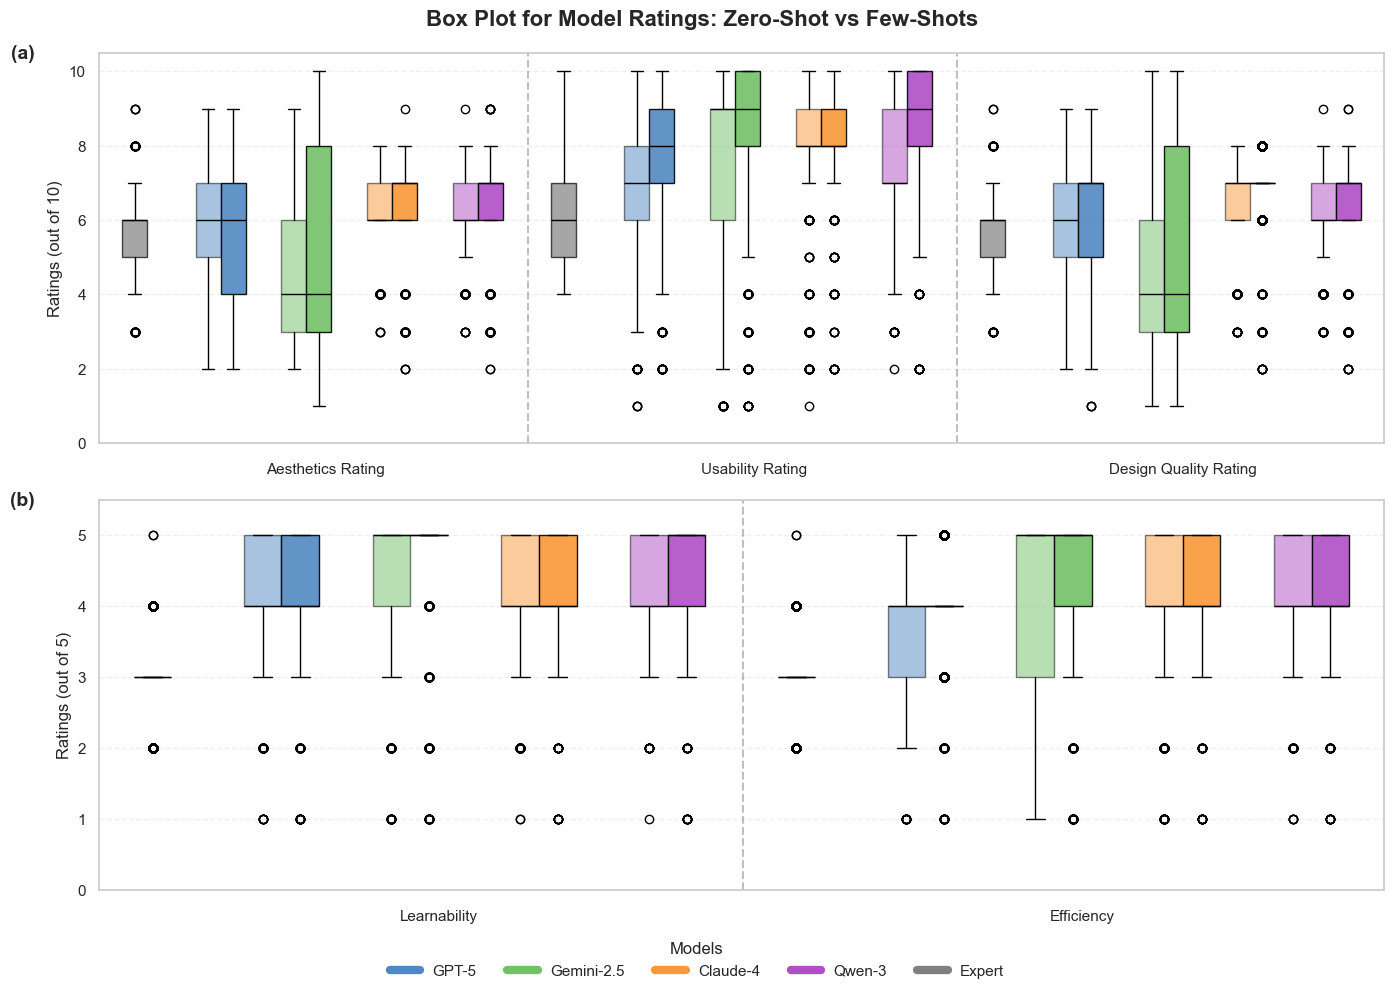

In [475]:
plot_clean_boxplots(
    plot_zs=plot_zs,
    plot_fs=plot_fs,
    model_order=order_zs,
    aspects_10=ASPECTS_10,
    aspects_5=ASPECTS_5,
    MODEL_COLORS=MODEL_COLORS
)


Histogram

In [ ]:
from scipy.stats import shapiro

def normality_check_with_experts(ratings_long, experts_df_filtered, alpha=0.05):
    results = []

    # Experts
    for aspect in EVALUATION_FIVE_ASPECTS:
        scores = experts_df_filtered[aspect].dropna()
        if len(scores) >= 3:
            stat, p = shapiro(scores)
            results.append({
                'model': 'Expert',
                'prompting': 'N/A',
                'aspect': aspect,
                'shapiro_W': stat,
                'p_value': p,
                'normal': p > alpha
            })

    # LLMs
    for (model, prompting, aspect), df in ratings_long.groupby(['model','prompting','aspect']):
        if model == 'Expert':
            continue
        scores = df['llm_score'].dropna()
        if len(scores) >= 3:
            stat, p = shapiro(scores)
            results.append({
                'model': model,
                'prompting': prompting,
                'aspect': aspect,
                'shapiro_W': stat,
                'p_value': p,
                'normal': p > alpha
            })

    return pd.DataFrame(results)


In [269]:
normality_df = normality_check_with_experts(ratings_long, experts_df_filtered)
normality_df


,model,prompting,aspect,shapiro_W,p_value,normal
0,Expert,N/A,aesthetics_rating,0.899375,4.414858e-25,False
1,Expert,N/A,learnability,0.777060,8.580795e-35,False
2,Expert,N/A,efficiency,0.798931,1.943292e-33,False
3,Expert,N/A,usability_rating,0.904504,1.678726e-24,False
4,Expert,N/A,design_quality_rating,0.896465,2.116985e-25,False
5,Claude-4,few_shot,aesthetics_rating,0.784966,2.847954e-34,False
6,Claude-4,few_shot,design_quality_rating,0.717030,5.540462e-38,False
7,Claude-4,few_shot,efficiency,0.663857,2.061491e-40,False
8,Claude-4,few_shot,learnability,0.667430,2.932517e-40,False
9,Claude-4,few_shot,usability_rating,0.693532,4.244887e-39,False


In [9]:
from scipy.stats import wilcoxon
from statsmodels.stats.multitest import multipletests

# # With Holm correction
# def wilcoxon_vs_expert(ratings_long, experts_df_filtered, alpha=0.05):
#     rows = []

#     for (prompting, aspect), df in ratings_long.groupby(['prompting','aspect']):
#         expert_scores = experts_df_filtered[['screen_task_id', aspect]].dropna()

#         for model in df['model'].unique():
#             if model == 'Expert':
#                 continue

#             model_scores = df[df['model'] == model][
#                 ['screen_task_id', 'llm_score']
#             ].dropna()

#             # Pairing by screen_task_id
#             paired = expert_scores.merge(
#                 model_scores,
#                 on='screen_task_id',
#                 how='inner'
#             )

#             if len(paired) < 10:
#                 continue

#             stat, p = wilcoxon(
#                 paired['llm_score'],
#                 paired[aspect],
#                 zero_method='wilcox'
#             )

#             rows.append({
#                 'prompting': prompting,
#                 'aspect': aspect,
#                 'model': model,
#                 'n_pairs': len(paired),
#                 'W': stat,
#                 'p_value': p
#             })

#     res = pd.DataFrame(rows)

#     # Holm correction (within each prompting × aspect)
#     res['p_holm'] = np.nan
#     res['significant'] = False

#     for (prompting, aspect), idx in res.groupby(['prompting','aspect']).groups.items():
#         pvals = res.loc[idx, 'p_value'].values
#         reject, p_corr, _, _ = multipletests(pvals, alpha=alpha, method='holm')
#         res.loc[idx, 'p_holm'] = p_corr
#         res.loc[idx, 'significant'] = reject

#     return res

def wilcoxon_vs_expert(ratings_long, experts_df_filtered, alpha=0.05):
    rows = []

    for (prompting, aspect), df in ratings_long.groupby(['prompting','aspect']):
        expert_scores = experts_df_filtered[['screen_task_id', aspect]].dropna()

        for model in df['model'].unique():
            if model == 'Expert':
                continue

            model_scores = (
                df[df['model'] == model][['screen_task_id', 'llm_score']]
                .dropna()
            )

            # Pair by screen_task_id
            paired = expert_scores.merge(
                model_scores,
                on='screen_task_id',
                how='inner'
            )

            n = len(paired)
            if n < 10:
                continue

            stat, p = wilcoxon(
                paired['llm_score'],
                paired[aspect],
                zero_method='wilcox'
            )

            # Calculate effect size r
            std = np.sqrt(n * (n + 1) * (2 * n + 1) / 24)
            u_w = n * (n + 1) / 4
            z = (stat - u_w) / std
            r = z / np.sqrt(n)

            rows.append({
                'prompting': prompting,
                'aspect': aspect,
                'model': model,
                'n_pairs': n,
                'W': stat,
                'p_value': p,
                'significant': p < alpha,
            })

    return pd.DataFrame(rows)

In [10]:
wilcoxon_df = wilcoxon_vs_expert(ratings_long, experts_df)
wilcoxon_df

,prompting,aspect,model,n_pairs,W,p_value,significant
0,few_shot,aesthetics_rating,GPT-5,997,164877.0,9.803807e-01,False
1,few_shot,aesthetics_rating,Gemini-2.5,997,148987.5,3.562049e-11,True
2,few_shot,aesthetics_rating,Claude-4,997,63491.5,5.527332e-45,True
3,few_shot,aesthetics_rating,Qwen-3,996,77111.5,1.717805e-35,True
4,few_shot,design_quality_rating,GPT-5,997,126189.5,2.883590e-07,True
5,few_shot,design_quality_rating,Gemini-2.5,997,157372.0,1.067792e-08,True
6,few_shot,design_quality_rating,Claude-4,997,48508.5,1.758815e-69,True
7,few_shot,design_quality_rating,Qwen-3,996,74841.5,3.627315e-39,True
8,few_shot,efficiency,GPT-5,997,36418.5,7.473897e-83,True
9,few_shot,efficiency,Gemini-2.5,997,36586.5,4.320290e-106,True


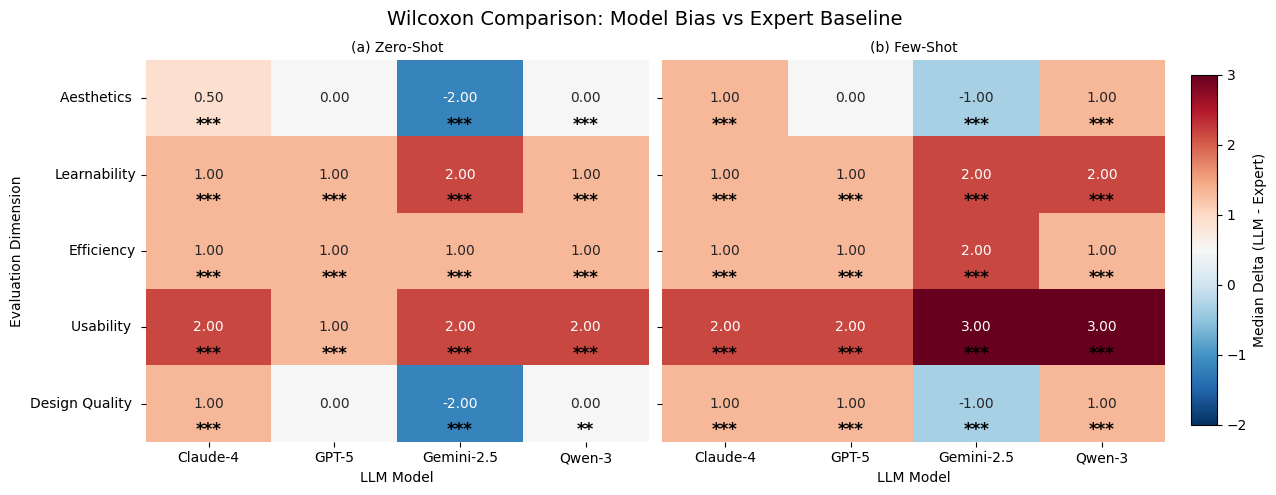

In [ ]:
# 1. Configuration & Helper Functions
def clean_aspect(name):
    return str(name).replace('rating', '').replace('_', ' ').title()

def clean_prompt(name):
    n = str(name).lower()
    if 'zero' in n or 'zs' in n: return '(a) Zero-Shot'
    if 'few' in n or 'fw' in n: return '(b) Few-Shot'
    return str(name).title()

# 2. Pre-process DataFrames
ratings_long['prompting_clean'] = ratings_long['prompting'].apply(clean_prompt)
ratings_long['aspect_clean'] = ratings_long['aspect'].apply(clean_aspect)
wilcoxon_df['prompting_clean'] = wilcoxon_df['prompting'].apply(clean_prompt)
wilcoxon_df['aspect_clean'] = wilcoxon_df['aspect'].apply(clean_aspect)

# Calculate medians
heatmap_base = ratings_long.groupby(['prompting_clean', 'aspect_clean', 'model'])['delta'].median().reset_index()

# Merge p-values
map_df = heatmap_base.merge(
    wilcoxon_df[['prompting_clean', 'aspect_clean', 'model', 'p_value']], 
    on=['prompting_clean', 'aspect_clean', 'model'],
    how='left'
)

CLEAN_ASPECT_ORDER = [clean_aspect(a) for a in EVALUATION_FIVE_ASPECTS]

def get_stars(p):
    if pd.isna(p): return ''
    if p < 0.001: return '***'
    elif p < 0.01: return '**'
    elif p < 0.05: return '*'
    return ''

# 3. Define the Draw Function
def draw_heatmap(data, **kwargs):
    # Pivot and enforce float
    pivot_delta = data.pivot(index="aspect_clean", columns="model", values="delta")
    pivot_delta = pivot_delta.reindex(CLEAN_ASPECT_ORDER).astype(float)
    
    pivot_p = data.pivot(index="aspect_clean", columns="model", values="p_value")
    pivot_p = pivot_p.reindex(CLEAN_ASPECT_ORDER)
    
    # We remove cbar=True from sns.heatmap so it doesn't draw it for every facet
    sns.heatmap(pivot_delta, cmap="RdBu_r", center=0, annot=True, fmt=".2f", 
                vmin=-2, vmax=3, cbar=False, **kwargs)
    
    # Overlay stars
    for y, aspect in enumerate(pivot_delta.index):
        for x, model in enumerate(pivot_delta.columns):
            p_val = pivot_p.loc[aspect, model]
            stars = get_stars(p_val)
            if stars:
                plt.text(x + 0.5, y + 0.85, stars, color='black', 
                         ha='center', va='center', fontsize=12, weight='bold')

# 4. Create the Figure with Space for a Single Colorbar
# We increase 'aspect' and 'height' slightly for readability
g = sns.FacetGrid(map_df, col="prompting_clean", col_order=['(a) Zero-Shot', '(b) Few-Shot'], 
                  height=5, aspect=1.3)

# Map the heatmaps
g.map_dataframe(draw_heatmap)

# 5. Create the Single Colorbar on the right
# Add a new axis for the colorbar [x, y, width, height]
cbar_ax = g.fig.add_axes([0.92, 0.15, 0.02, 0.7]) 

# Generate a colorbar based on the scale used (-2 to 3)
norm = plt.Normalize(-2, 3)
sm = plt.cm.ScalarMappable(cmap="RdBu_r", norm=norm)
sm.set_array([])
g.fig.colorbar(sm, cax=cbar_ax, label='Median Delta (LLM - Expert)')

# Final formatting
g.set_axis_labels("LLM Model", "Evaluation Dimension")
g.set_titles("{col_name}")
plt.subplots_adjust(top=0.88, right=0.9)
g.fig.suptitle("Wilcoxon Comparison: Model Bias vs Expert Baseline", fontsize=14)

plt.show()

In [27]:
# To find the absolute maximum delta value in the entire ratings_long dataframe
max_delta = ratings_long['delta'].max()
print(f"The maximum delta value is: {max_delta}")

The maximum delta value is: 6.0


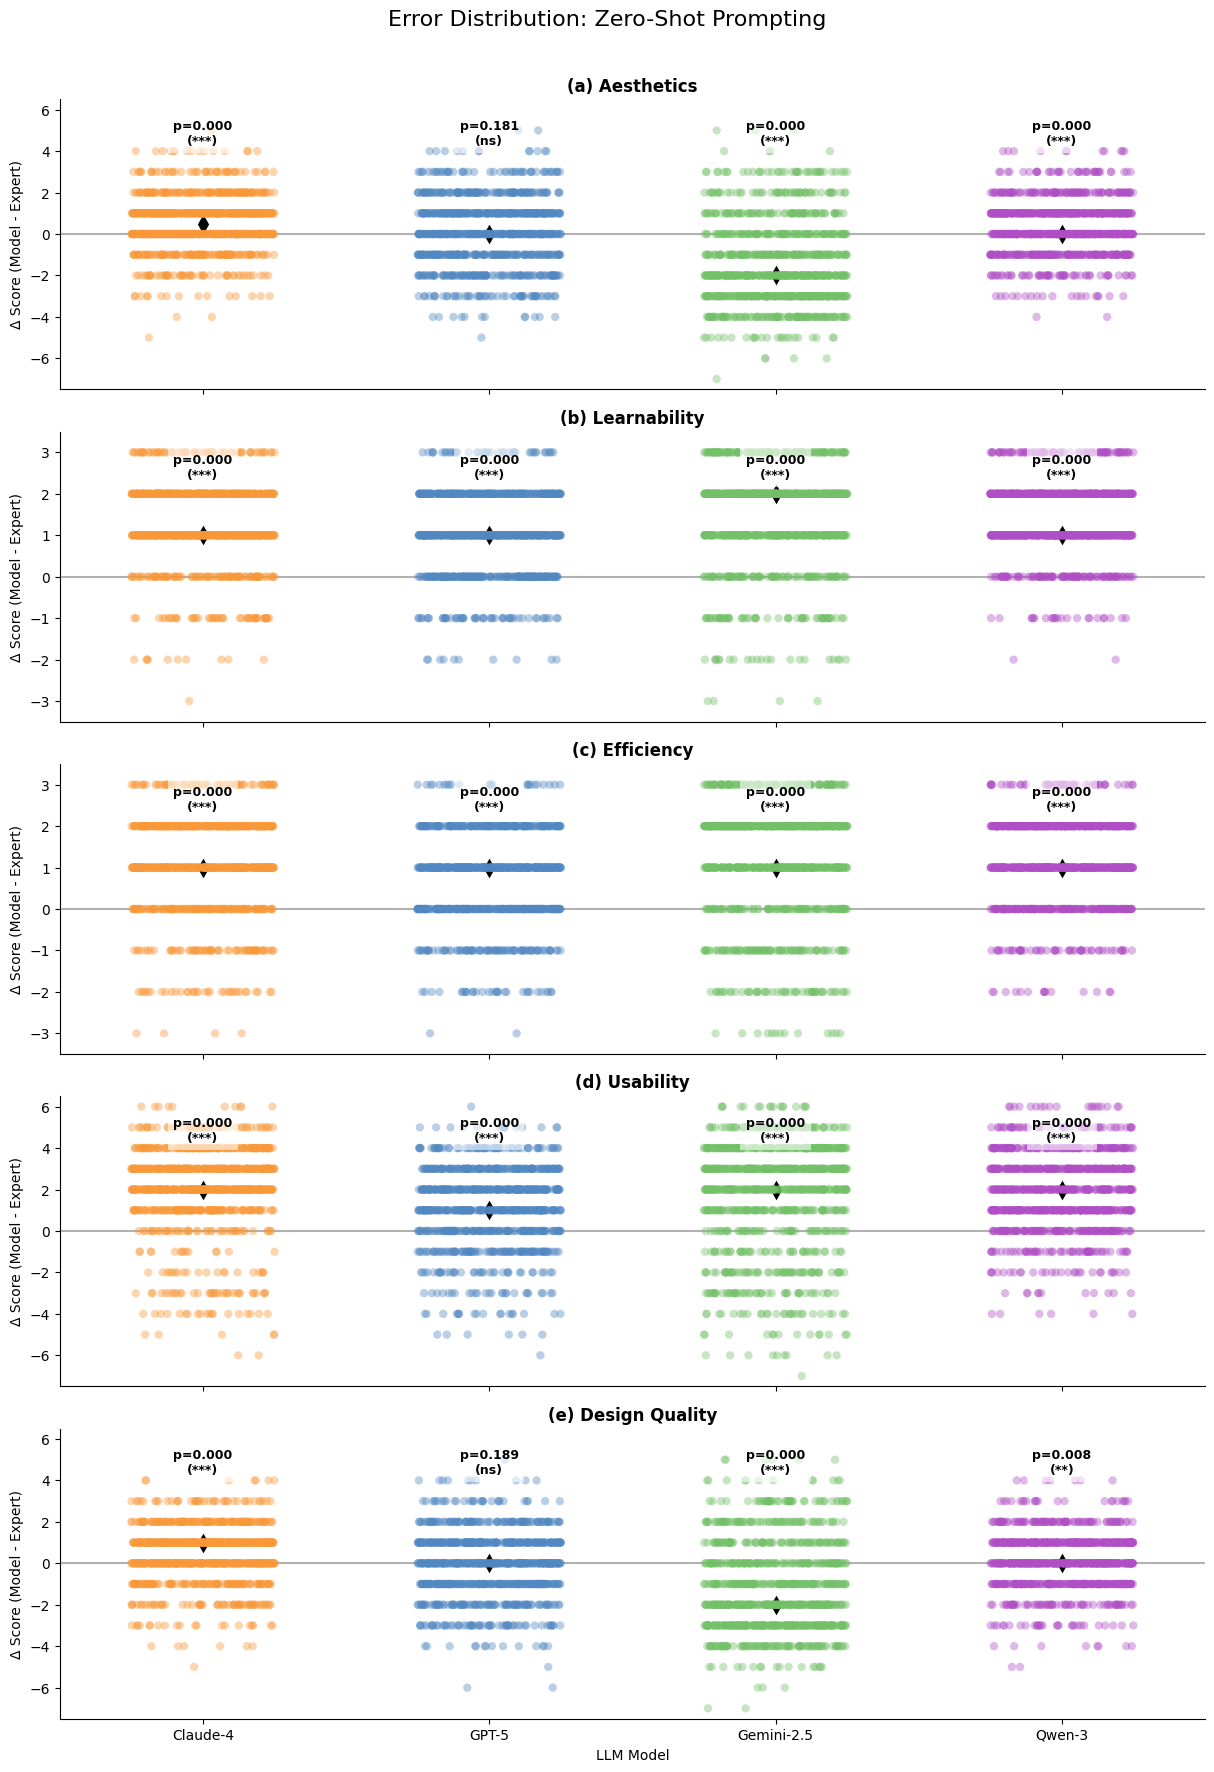

In [ ]:
# 1. Configuration
target_prompt_raw = 'zero_shot' 
display_prompt = 'Zero-Shot'

# Filter data
plot_df = ratings_long[ratings_long['prompting'].str.strip().str.lower() == target_prompt_raw.lower()].copy()

# Define Alphabetical Model Order
MODEL_ORDER = sorted(plot_df['model'].unique())

# 2. Setup the FacetGrid
g = sns.FacetGrid(
    plot_df, 
    row="aspect", 
    row_order=EVALUATION_FIVE_ASPECTS,
    height=3.5, 
    aspect=3.5, 
    sharey=False 
)

def draw_wilcoxon_view(data, **kwargs):
    ax = plt.gca()
    current_aspect = data['aspect'].iloc[0]
    
    # a) Set consistent Y-limits
    if current_aspect in ASPECTS_10:
        ax.set_ylim(-7.5, 6.5) 
    elif current_aspect in ASPECTS_5:
        ax.set_ylim(-3.5, 3.5) 
    
    # b) Draw the zero-reference line
    ax.axhline(0, color=MODEL_COLORS["Expert"], linestyle='-', linewidth=1.5, alpha=0.8)
    
    # c) Draw individual deltas with EXPLICIT ORDER
    sns.stripplot(
        data=data, x='model', y='delta', order=MODEL_ORDER, hue='model', 
        palette=MODEL_COLORS, alpha=0.4, size=6, jitter=0.25, legend=False, ax=ax
    )
    
    # d) Draw median diamonds with EXPLICIT ORDER
    sns.pointplot(
        data=data, x='model', y='delta', order=MODEL_ORDER, color='black', 
        estimator='median', errorbar=None, markers='d', linestyles='', ax=ax
    )

    # e) Annotate p-values using the sorted order index
    for i, model in enumerate(MODEL_ORDER):
        stats = wilcoxon_df[
            (wilcoxon_df['model'] == model) & 
            (wilcoxon_df['aspect'] == current_aspect) &
            (wilcoxon_df['prompting'] == target_prompt_raw)
        ]
        
        if not stats.empty:
            p_val = stats['p_value'].values[0]
            stars = '***' if p_val < 0.001 else '**' if p_val < 0.01 else '*' if p_val < 0.05 else 'ns'
            
            y_max = ax.get_ylim()[1]
            ax.text(i, y_max * 0.85, f"p={p_val:.3f}\n({stars})", 
                     ha='center', va='top', fontsize=9, fontweight='bold', 
                     bbox=dict(facecolor='white', alpha=0.6, edgecolor='none'))

# 3. Map and Apply Formatting
g.map_dataframe(draw_wilcoxon_view)

# Customizing row titles: Removing "Rating" and applying formatting
for ax, title in zip(g.axes.flat, EVALUATION_FIVE_ASPECTS):
    index = EVALUATION_FIVE_ASPECTS.index(title)
    letter = chr(97 + index)
    
    # --- FIXED: Remove 'rating' and format title ---
    clean_name = title.lower().replace('rating', '').replace('_', ' ').strip().title()
    clean_title = f"({letter}) {clean_name}"
    
    ax.set_title(clean_title, fontweight='bold', loc='center')

g.set_axis_labels("LLM Model", "Δ Score (Model - Expert)")
g.fig.suptitle(f"Error Distribution: {display_prompt} Prompting", y=1.01, fontsize=16)

plt.tight_layout()

In [31]:
# This looks for the most extreme values in the raw data
print(ratings_long.nsmallest(5, 'delta')[['model', 'aspect', 'delta']])

           model                 aspect  delta
5966  Gemini-2.5      aesthetics_rating   -7.0
8367  Gemini-2.5       usability_rating   -7.0
9742  Gemini-2.5  design_quality_rating   -7.0
9966  Gemini-2.5  design_quality_rating   -7.0
3742       GPT-5       usability_rating   -6.0


In [ ]:
def cliffs_delta(x, y):
    x = np.asarray(x)
    y = np.asarray(y)
    n_x, n_y = len(x), len(y)
    gt = sum(xi > yj for xi in x for yj in y)
    lt = sum(xi < yj for xi in x for yj in y)
    return (gt - lt) / (n_x * n_y)

def effect_size_vs_expert(ratings_long, experts_df_filtered):
    rows = []

    for (prompting, aspect), df in ratings_long.groupby(['prompting','aspect']):
        exp = experts_df_filtered[['screen_task_id', aspect]].dropna()

        for model in df['model'].unique():
            if model == 'Expert':
                continue

            mod = df[df['model'] == model][['screen_task_id','llm_score']].dropna()
            paired = exp.merge(mod, on='screen_task_id', how='inner')

            if len(paired) < 10:
                continue

            delta_vals = paired['llm_score'] - paired[aspect]

            rows.append({
                'prompting': prompting,
                'aspect': aspect,
                'model': model,
                'n_pairs': len(paired),
                'r': 
                'median_delta': np.median(delta_vals),
                'cliffs_delta': cliffs_delta(paired['llm_score'], paired[aspect])
            })

    return pd.DataFrame(rows)


In [ ]:
effect_df = effect_size_vs_expert(ratings_long, experts_df_filtered)
effect_df


,prompting,aspect,model,n_pairs,median_delta,cliffs_delta
0,few_shot,aesthetics_rating,GPT-5,997,0.0,0.074678
1,few_shot,aesthetics_rating,Gemini-2.5,997,-1.0,-0.106557
2,few_shot,aesthetics_rating,Claude-4,997,1.0,0.435054
3,few_shot,aesthetics_rating,Qwen-3,996,1.0,0.413698
4,few_shot,design_quality_rating,GPT-5,997,1.0,0.219752
5,few_shot,design_quality_rating,Gemini-2.5,997,-1.0,-0.108288
6,few_shot,design_quality_rating,Claude-4,997,1.0,0.562247
7,few_shot,design_quality_rating,Qwen-3,996,1.0,0.451778
8,few_shot,efficiency,GPT-5,997,1.0,0.579444
9,few_shot,efficiency,Gemini-2.5,997,2.0,0.683413


In [38]:
from irrCAC.raw import CAC

def bp_kappa_vs_expert(ratings_long, experts_df_filtered, categories_dict):
    rows = []

    for (prompting, aspect), df in ratings_long.groupby(['prompting','aspect']):
        exp = experts_df_filtered[['screen_task_id', aspect]].dropna()

        for model in df['model'].unique():
            if model == 'Expert':
                continue

            mod = df[df['model'] == model][['screen_task_id','llm_score']].dropna()
            paired = exp.merge(mod, on='screen_task_id', how='inner')

            if len(paired) < 10:
                continue

            ratings_mat = pd.DataFrame({
            'Expert': paired[aspect].values,
            'Model': paired['llm_score'].values
            })

            cac = CAC(
                ratings=ratings_mat,
                categories=categories_dict[aspect],
                weights='quadratic'
            )

            res = cac.bp()

            rows.append({
                'prompting': prompting,
                'aspect': aspect,
                'model': model,
                'n_pairs': len(paired),
                'bp_kappa': res['est']['coefficient_value'],
                'ci_low': res['est']['confidence_interval'][0],
                'ci_high': res['est']['confidence_interval'][1],
                'p_value': res['est']['p_value']
            })

    return pd.DataFrame(rows)

In [39]:
bp_df = bp_kappa_vs_expert(ratings_long, experts_df_filtered, CATEGORIES_DICT)
bp_df

,prompting,aspect,model,n_pairs,bp_kappa,ci_low,ci_high,p_value
0,few_shot,aesthetics_rating,GPT-5,997,0.77441,0.75722,0.79161,0.000000e+00
1,few_shot,aesthetics_rating,Gemini-2.5,997,0.61740,0.59456,0.64024,0.000000e+00
2,few_shot,aesthetics_rating,Claude-4,997,0.82706,0.81180,0.84231,0.000000e+00
3,few_shot,aesthetics_rating,Qwen-3,996,0.81660,0.80130,0.83190,0.000000e+00
4,few_shot,design_quality_rating,GPT-5,997,0.79095,0.77445,0.80744,0.000000e+00
5,few_shot,design_quality_rating,Gemini-2.5,997,0.59478,0.57138,0.61819,0.000000e+00
6,few_shot,design_quality_rating,Claude-4,997,0.81581,0.80056,0.83106,0.000000e+00
7,few_shot,design_quality_rating,Qwen-3,996,0.81520,0.80003,0.83037,0.000000e+00
8,few_shot,efficiency,GPT-5,997,0.52257,0.48987,0.55527,0.000000e+00
9,few_shot,efficiency,Gemini-2.5,997,0.18731,0.14495,0.22968,0.000000e+00


In [42]:
# Pivot so we get ZS and FS side-by-side
pivot = (
    bp_df
    .pivot_table(
        index=["model", "aspect"],
        columns="prompting",
        values="bp_kappa"
    )
    .reset_index()
)

# Make sure column names match yours (e.g., "zero_shot", "few_shot")
pivot["kappa_drop"] = pivot["zero_shot"] - pivot["few_shot"]
pivot["kappa_drop"]


0     0.05215
1     0.06316
2    -0.06837
3    -0.03950
4     0.02356
5     0.06092
6     0.05329
7     0.08218
8     0.13817
9     0.13350
10    0.00454
11    0.04098
12    0.01994
13    0.08655
14    0.19025
15    0.07214
16    0.07275
17    0.04156
18    0.19048
19    0.27288
Name: kappa_drop, dtype: float64

In [ ]:
from sklearn.metrics import root_mean_squared_error

def rmse_vs_expert(ratings_long, experts_df_filtered):
    rows = []

    for (prompting, aspect), df in ratings_long.groupby(['prompting','aspect']):
        exp = experts_df_filtered[['screen_task_id', aspect]].dropna()

        for model in df['model'].unique():
            if model == 'Expert':
                continue

            mod = df[df['model'] == model][['screen_task_id','llm_score']].dropna()
            paired = exp.merge(mod, on='screen_task_id', how='inner')

            if len(paired) < 10:
                continue

            rmse = root_mean_squared_error(
                paired[aspect], paired['llm_score']
            )

            rows.append({
                'prompting': prompting,
                'aspect': aspect,
                'model': model,
                'n_pairs': len(paired),
                'rmse': rmse
            })

    return pd.DataFrame(rows)

In [ ]:
rmse_df = rmse_vs_expert(ratings_long, experts_df_filtered)
rmse_df

,prompting,aspect,model,n_pairs,rmse
0,few_shot,aesthetics_rating,GPT-5,997,1.929292
1,few_shot,aesthetics_rating,Gemini-2.5,997,2.512556
2,few_shot,aesthetics_rating,Claude-4,997,1.689249
3,few_shot,aesthetics_rating,Qwen-3,996,1.739570
4,few_shot,design_quality_rating,GPT-5,997,1.857242
5,few_shot,design_quality_rating,Gemini-2.5,997,2.585741
6,few_shot,design_quality_rating,Claude-4,997,1.743306
7,few_shot,design_quality_rating,Qwen-3,996,1.746195
8,few_shot,efficiency,GPT-5,997,1.381930
9,few_shot,efficiency,Gemini-2.5,997,1.802984


In [ ]:
def plot_hybrid_metric_from_df(
    df,
    value_col,
    aspects=None,
    title=None,
    ylabel=None,
    ylim=None,
    ax=None  # new optional argument
):
    """
    Generic hybrid plot for Zero-shot vs Few-shot, now supports existing axes.
    """
    # split by prompting
    df_zs = df[df['prompting']=="zero_shot"].pivot(index='model', columns='aspect', values=value_col)
    df_fs = df[df['prompting']=="few_shot"].pivot(index='model', columns='aspect', values=value_col)

    # consistent models and metrics order
    models = [m for m in df_zs.index if m in df_fs.index]
    if aspects is None:
        aspects = df.columns[df.columns != 'model'].tolist()
    df_zs = df_zs.reindex(index=models, columns=aspects)
    df_fs = df_fs.reindex(index=models, columns=aspects)

    model_colors = MODEL_COLORS

    bar_width = 0.18
    gap_within_model = 0.02
    gap_between_models = 0.10
    gap_between_metrics = 0.50

    per_model_block = 2 * bar_width + gap_within_model
    per_metric_block = len(models) * per_model_block + (len(models) - 1) * gap_between_models

    metric_centers = []
    x_positions_zs, x_positions_fs = {}, {}

    for mi, metric in enumerate(aspects):
        base = mi * (per_metric_block + gap_between_metrics)
        cursor = base
        for model in models:
            x_positions_zs[(model, metric)] = cursor
            x_positions_fs[(model, metric)] = cursor + bar_width + gap_within_model
            cursor += per_model_block + gap_between_models
        metric_centers.append(base + per_metric_block / 2.0)

    # --- use existing ax if provided, else create new figure ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(12, 6))

    for model in models:
        zs_heights = [df_zs.loc[model, m] for m in aspects]
        fs_heights = [df_fs.loc[model, m] for m in aspects]
        zs_x = [x_positions_zs[(model, m)] for m in aspects]
        fs_x = [x_positions_fs[(model, m)] for m in aspects]
        color = model_colors[model]

        ax.bar(zs_x, zs_heights, width=bar_width, color=color, alpha=0.5, label=f"{model} Zero-shot")
        ax.bar(fs_x, fs_heights, width=bar_width, color=color, alpha=0.9, label=f"{model} Few-shot")

        # connector lines
        for x1, y1, x2, y2 in zip(zs_x, zs_heights, fs_x, fs_heights):
            ax.plot([x1 + bar_width/2, x2 + bar_width/2], [y1, y2],
                    marker='o', markersize=4, color=color, alpha=0.7, linewidth=1)

    ax.set_title(title if title else f"{ylabel}: Zero-shot vs Few-shot", fontsize=13, weight="bold")
    ax.set_ylabel(ylabel if ylabel else value_col)
    ax.set_xticks(metric_centers)
    ax.set_xticklabels([a.replace('rating', '').replace('_', ' ').title() for a in aspects], rotation=20, ha='right')

    if ylim is not None:
        ax.set_ylim(*ylim)
    else:
        ax.set_ylim(0, 1.0 if value_col == 'bp_kappa' else None)

    ax.grid(axis='both', linestyle='--', alpha=0.3)

    handles, labels = ax.get_legend_handles_labels()

    # two rows: first row Zero-shot, second row Few-shot
    zs_handles = [h for h, l in zip(handles, labels) if "Zero-shot" in l]
    zs_labels  = [l for l in labels if "Zero-shot" in l]
    fs_handles = [h for h, l in zip(handles, labels) if "Few-shot" in l]
    fs_labels  = [l for l in labels if "Few-shot" in l]

    # combine handles for legend (first row ZS, second row FS)
    combined_handles = zs_handles + fs_handles
    combined_labels = zs_labels + fs_labels

    ax.legend(
        combined_handles, combined_labels,
        ncol=len(zs_handles),  # first row: Zero-shot models
        loc='upper center', bbox_to_anchor=(0.5, -0.15),
        frameon=False, fontsize=9
    )

    if ax is None:
        plt.tight_layout()
        plt.show()


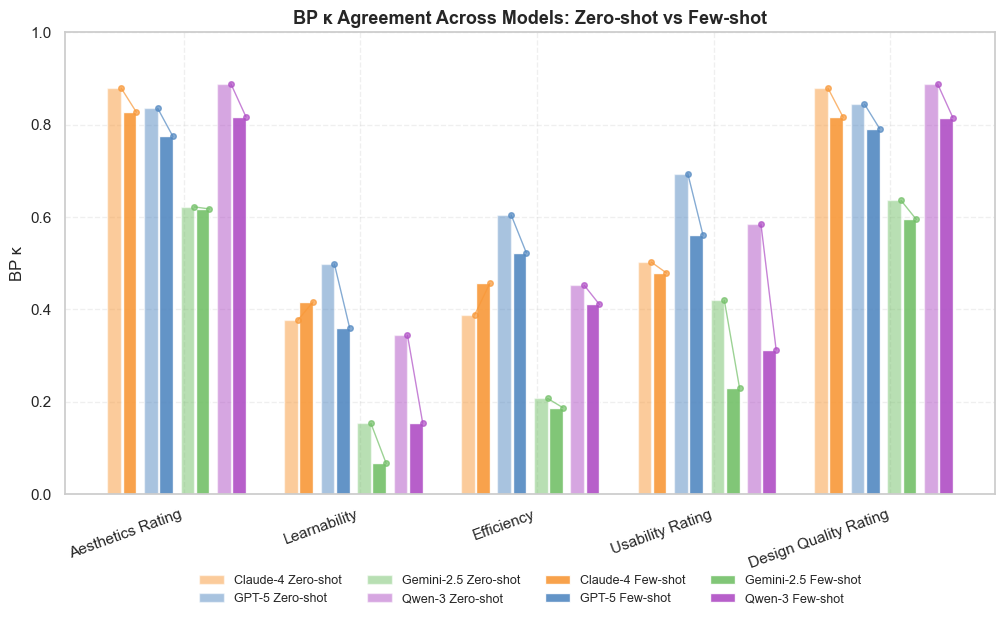

In [462]:
plot_hybrid_metric_from_df(bp_df, value_col='bp_kappa', aspects=EVALUATION_FIVE_ASPECTS, ylabel="BP κ",
                           title="BP κ Agreement Across Models: Zero-shot vs Few-shot")

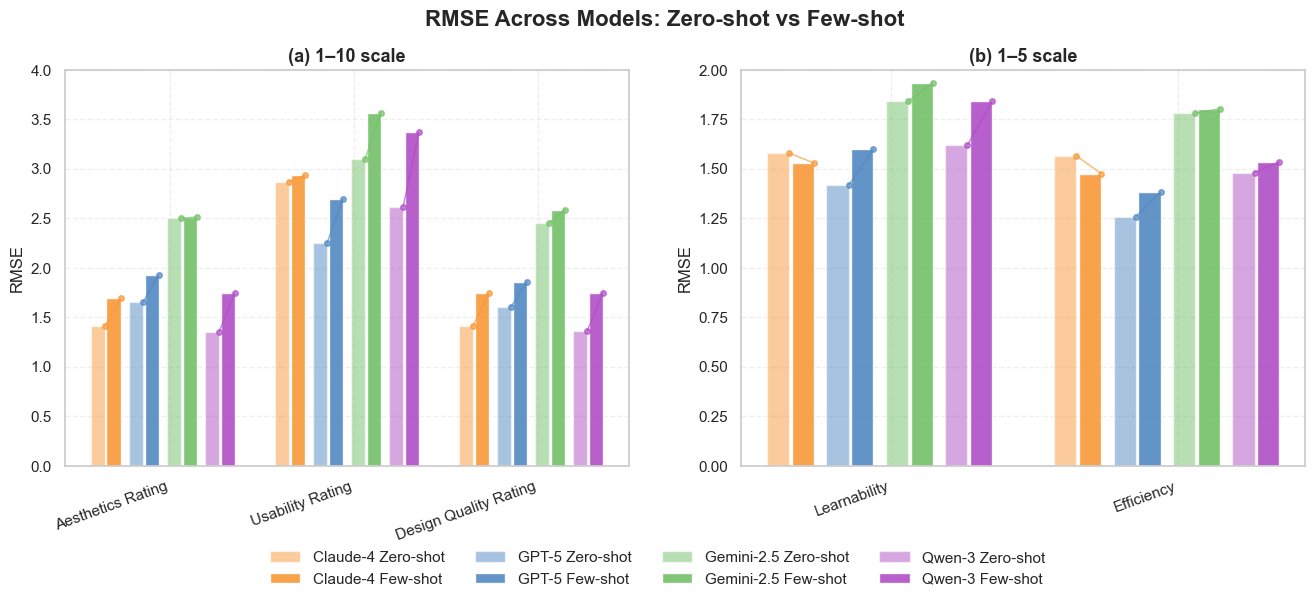

In [471]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(16, 6),  # adjust width/height as needed
    sharey=False
)

# --- Subplot (a): 1–10 scale ---
plot_hybrid_metric_from_df(
    df=rmse_df,
    value_col='rmse',
    aspects=ASPECTS_10,
    title="(a) 1–10 scale",
    ylabel="RMSE",
    ylim=(0, 4),
    ax=axes[0]  # pass the axis
)

# --- Subplot (b): 1–5 scale ---
plot_hybrid_metric_from_df(
    df=rmse_df,
    value_col='rmse',
    aspects=ASPECTS_5,
    title="(b) 1–5 scale",
    ylabel="RMSE",
    ylim=(0, 2),
    ax=axes[1]  # pass the axis
)
# remove legend from the right subplot
handles, labels = axes[0].get_legend_handles_labels()
axes[0].get_legend().remove()
axes[1].get_legend().remove()

fig.legend(
    handles, labels,
    loc="lower center",
    ncol=len([l for l in labels if "Zero-shot" in l]),
    frameon=False
)

fig.suptitle(
    "RMSE Across Models: Zero-shot vs Few-shot",
    fontsize=16,
    fontweight="bold"
)

fig.subplots_adjust(bottom=0.22)   # push subplots up so legend doesn't overlap ticks
plt.show()


In [ ]:
def discrepancy_heatmap(ratings_long, experts_df_filtered, aspect, bins, labels):
    rows = []
    exp = experts_df_filtered[['screen_task_id', aspect]].dropna()

    for (model, prompting), df in ratings_long[ratings_long['aspect']==aspect].groupby(['model','prompting']):
        if model == 'Expert': 
            continue

        mod = df[['screen_task_id','llm_score']].dropna()
        paired = exp.merge(mod, on='screen_task_id', how='inner')
        if paired.empty:
            continue

        paired['bin'] = pd.cut(paired[aspect], bins=bins, labels=labels, include_lowest=True)
        paired['abs_err'] = (paired['llm_score'] - paired[aspect]).abs()

        for b, g in paired.groupby('bin', observed=False):
            rows.append({
                'model': model,
                'prompting': prompting,
                'bin': b,
                'mae': g['abs_err'].mean()
            })

    heat_df = pd.DataFrame(rows)
    return heat_df

def plot_discrepancy_heatmap(heat_df, prompting, title):
    df = heat_df[heat_df['prompting']==prompting].pivot(index='model', columns='bin', values='mae')
    # enforce order safely (keeps existing cols, adds missing)
    # reorder columns by prefix Low/Mid/High based on existing labels
    order = sorted(df.columns, key=lambda s: {'Low':0,'Mid':1,'High':2}.get(str(s).split()[0], 99))
    df = df[order]
    
    plt.figure(figsize=(8, 4))
    sns.heatmap(df, annot=True, fmt=".2f", cmap="Reds")
    plt.title(title)
    plt.xlabel("Expert score bin")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()

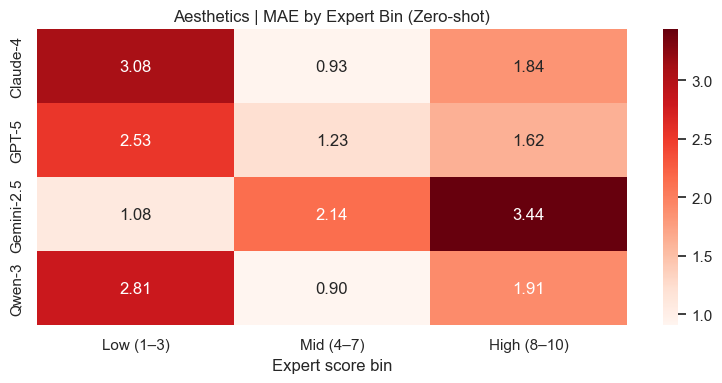

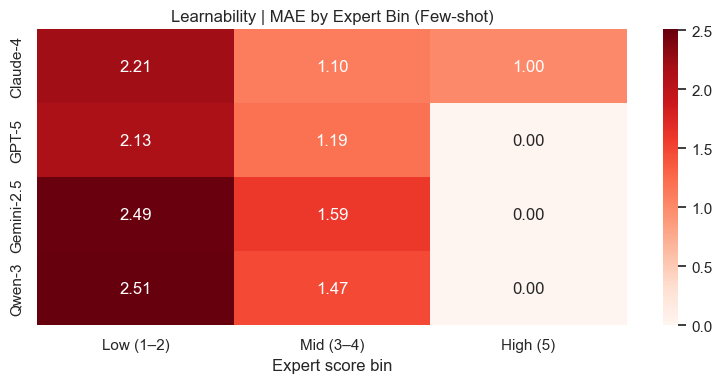

In [ ]:
# out of 10
bins10 = [0,3,7,10]
labels10 = ['Low (1–3)','Mid (4–7)','High (8–10)']
heat10 = discrepancy_heatmap(ratings_long, experts_df_filtered, 'aesthetics_rating', bins10, labels10)
plot_discrepancy_heatmap(heat10, 'zero_shot', 'Aesthetics | MAE by Expert Bin (Zero-shot)')

# out of 5
bins5 = [0,2,4,5]
labels5 = ['Low (1–2)','Mid (3–4)','High (5)']
heat5 = discrepancy_heatmap(ratings_long, experts_df_filtered, 'learnability', bins5, labels5)
plot_discrepancy_heatmap(heat5, 'few_shot', 'Learnability | MAE by Expert Bin (Few-shot)')

Summary


In [171]:
def build_summary_table(bp_df, rmse_df, effect_df):
    # Mean κ per model × prompting
    kappa = (
        bp_df.groupby(['model','prompting'])['bp_kappa']
        .mean()
        .reset_index(name='mean_bp_kappa')
    )

    # Mean RMSE per model × prompting
    rmse = (
        rmse_df.groupby(['model','prompting'])['rmse']
        .mean()
        .reset_index(name='mean_rmse')
    )

    # Median bias (Δ) per model × prompting
    bias = (
        effect_df.groupby(['model','prompting'])['median_delta']
        .median()
        .reset_index(name='median_delta')
    )

    # Merge all
    summary = (
        kappa
        .merge(rmse, on=['model','prompting'], how='inner')
        .merge(bias, on=['model','prompting'], how='inner')
        .sort_values(['prompting','model'])
        .reset_index(drop=True)
    )

    return summary

In [173]:
summary_table = build_summary_table(bp_df, rmse_df, effect_df)
summary_table.round({
    'mean_bp_kappa': 3,
    'mean_rmse': 3,
    'median_delta': 2
})
summary_table

,model,prompting,mean_bp_kappa,mean_rmse,median_delta
0,Claude-4,few_shot,0.598820,1.873593,1.0
1,GPT-5,few_shot,0.601776,1.892117,1.0
2,Gemini-2.5,few_shot,0.339128,2.479824,2.0
3,Qwen-3,few_shot,0.501690,2.045886,1.0
4,Claude-4,zero_shot,0.605020,1.766810,1.0
5,GPT-5,zero_shot,0.695388,1.634344,1.0
6,Gemini-2.5,zero_shot,0.407580,2.332918,1.0
7,Qwen-3,zero_shot,0.631652,1.686113,1.0


# Explore Results

## LLM Consistency (intra-model)

In [ ]:
def prepare_llm_vs_expert_df(responses_df, experts_df_filtered, FIVE_METRICS):
    """
    Processes LLM responses and merges with expert ratings.
    Returns merged DataFrame with LLM means/stds and expert ratings.
    """
    # --- STEP 1: Melt LLM responses to long format ---
    llm_long = responses_df.melt(
        id_vars=['screen_task_id', 'screen_id'],
        value_vars=FIVE_METRICS,
        var_name='metric',
        value_name='rating'
    )

    # --- STEP 2: Aggregate over the 10 runs per screen-task-metric ---
    llm_agg = llm_long.groupby(['screen_task_id', 'screen_id', 'metric']).agg(
        llm_mean=('rating', 'mean'),
        llm_std=('rating', 'std')
    ).reset_index()

    # --- STEP 3: Pivot to wide format (metrics as columns) ---
    llm_wide = llm_agg.pivot_table(
        index=['screen_task_id', 'screen_id'],
        columns='metric',
        values=['llm_mean', 'llm_std']
    )
    llm_wide.columns = [f"{lvl2}_{lvl1}" for lvl1, lvl2 in llm_wide.columns]  # flatten columns
    llm_wide = llm_wide.reset_index()

    # Reorder columns to match original order
    ordered_columns = ['screen_task_id', 'screen_id'] + \
        [f"{metric}_llm_mean" for metric in FIVE_METRICS] + \
        [f"{metric}_llm_std" for metric in FIVE_METRICS]
    llm_wide = llm_wide[ordered_columns]

    # --- STEP 4: Merge with expert ratings ---
    merged_df = experts_df_filtered.merge(llm_wide, on=['screen_task_id', 'screen_id'], how='inner')
    merged_df = merged_df.sort_values(by='screen_id').reset_index(drop=True)
    return merged_df

In [ ]:
merged_gpt_df = prepare_llm_vs_expert_df(gpt_df, experts_df_filtered, EVALUATION_FIVE_ASPECTS)
merged_claude_df = prepare_llm_vs_expert_df(claude_df, experts_df_filtered, EVALUATION_FIVE_ASPECTS)
merged_gemini_df = prepare_llm_vs_expert_df(gemini_df, experts_df_filtered, EVALUATION_FIVE_ASPECTS)
merged_gemini_df.head(1)

,screen_task_id,screen_id,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating,aesthetics_rating_llm_mean,learnability_llm_mean,efficiency_llm_mean,usability_rating_llm_mean,design_quality_rating_llm_mean,aesthetics_rating_llm_std,learnability_llm_std,efficiency_llm_std,usability_rating_llm_std,design_quality_rating_llm_std
0,15_T01,15,6,3,3,6,6,4.5,3.5,3.5,6.1,4.0,0.707107,0.527046,0.707107,1.523884,0.0


### Compute mean std across all screens

In [9]:
def get_mean_std_per_metric(merged_df):
    """
    Compute mean standard deviation across all screens for each metric.
    """
    std_cols = [c for c in merged_df.columns if c.endswith('_llm_std')]
    mean_std = merged_df[std_cols].mean()
    mean_std.index = mean_std.index.str.replace('_llm_std', '')
    return mean_std.round(2)

# Compute for each model
gpt_std = get_mean_std_per_metric(merged_gpt_df)
claude_std = get_mean_std_per_metric(merged_claude_df)
gemini_std = get_mean_std_per_metric(merged_gemini_df)

# Combine into one DataFrame
std_comparison_df = pd.DataFrame({
    'GPT': gpt_std,
    'Claude': claude_std,
    'Gemini': gemini_std
}).T  # transpose so models are rows

print("Standard Deviation Average per Metric:")
std_comparison_df

Standard Deviation Average per Metric:


,aesthetics_rating,learnability,efficiency,usability_rating,design_quality_rating
GPT,0.16,0.07,0.14,0.21,0.13
Claude,0.10,0.02,0.03,0.07,0.12
Gemini,0.56,0.29,0.36,0.71,0.59


### Visualizations

#### Standard Deviation Analysis of LLM Ratings

In [ ]:
def melt_std_long(merged_df):
    """
    Convert LLM std columns in a merged_df into long format for plotting/analysis.
    
    Parameters:
        merged_df (pd.DataFrame): DataFrame with *_llm_std columns.
    
    Returns:
        pd.DataFrame: Long-format dataframe with columns [screen_task_id, metric, std].
    """
    std_cols = [c for c in merged_df.columns if c.endswith('_llm_std')]
    std_long = merged_df.melt(
        id_vars=['screen_task_id'],
        value_vars=std_cols,
        var_name='metric',
        value_name='std'
    )
    std_long['metric'] = std_long['metric'].str.replace('_llm_std', '')
    return std_long

# Example usage:
gpt_std_long = melt_std_long(merged_gpt_df)
claude_std_long = melt_std_long(merged_claude_df)
gemini_std_long = melt_std_long(merged_gemini_df)

gpt_std_long['model'] = 'GPT-4'
claude_std_long['model'] = 'Claude-4'
gemini_std_long['model'] = 'Gemini-2.5'

all_std_long = pd.concat([gpt_std_long, claude_std_long, gemini_std_long], ignore_index=True)

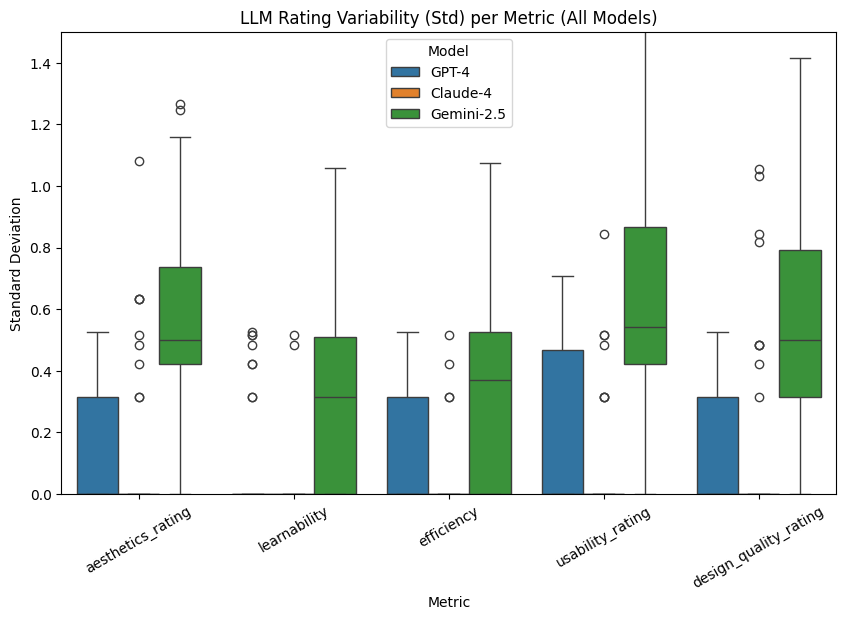

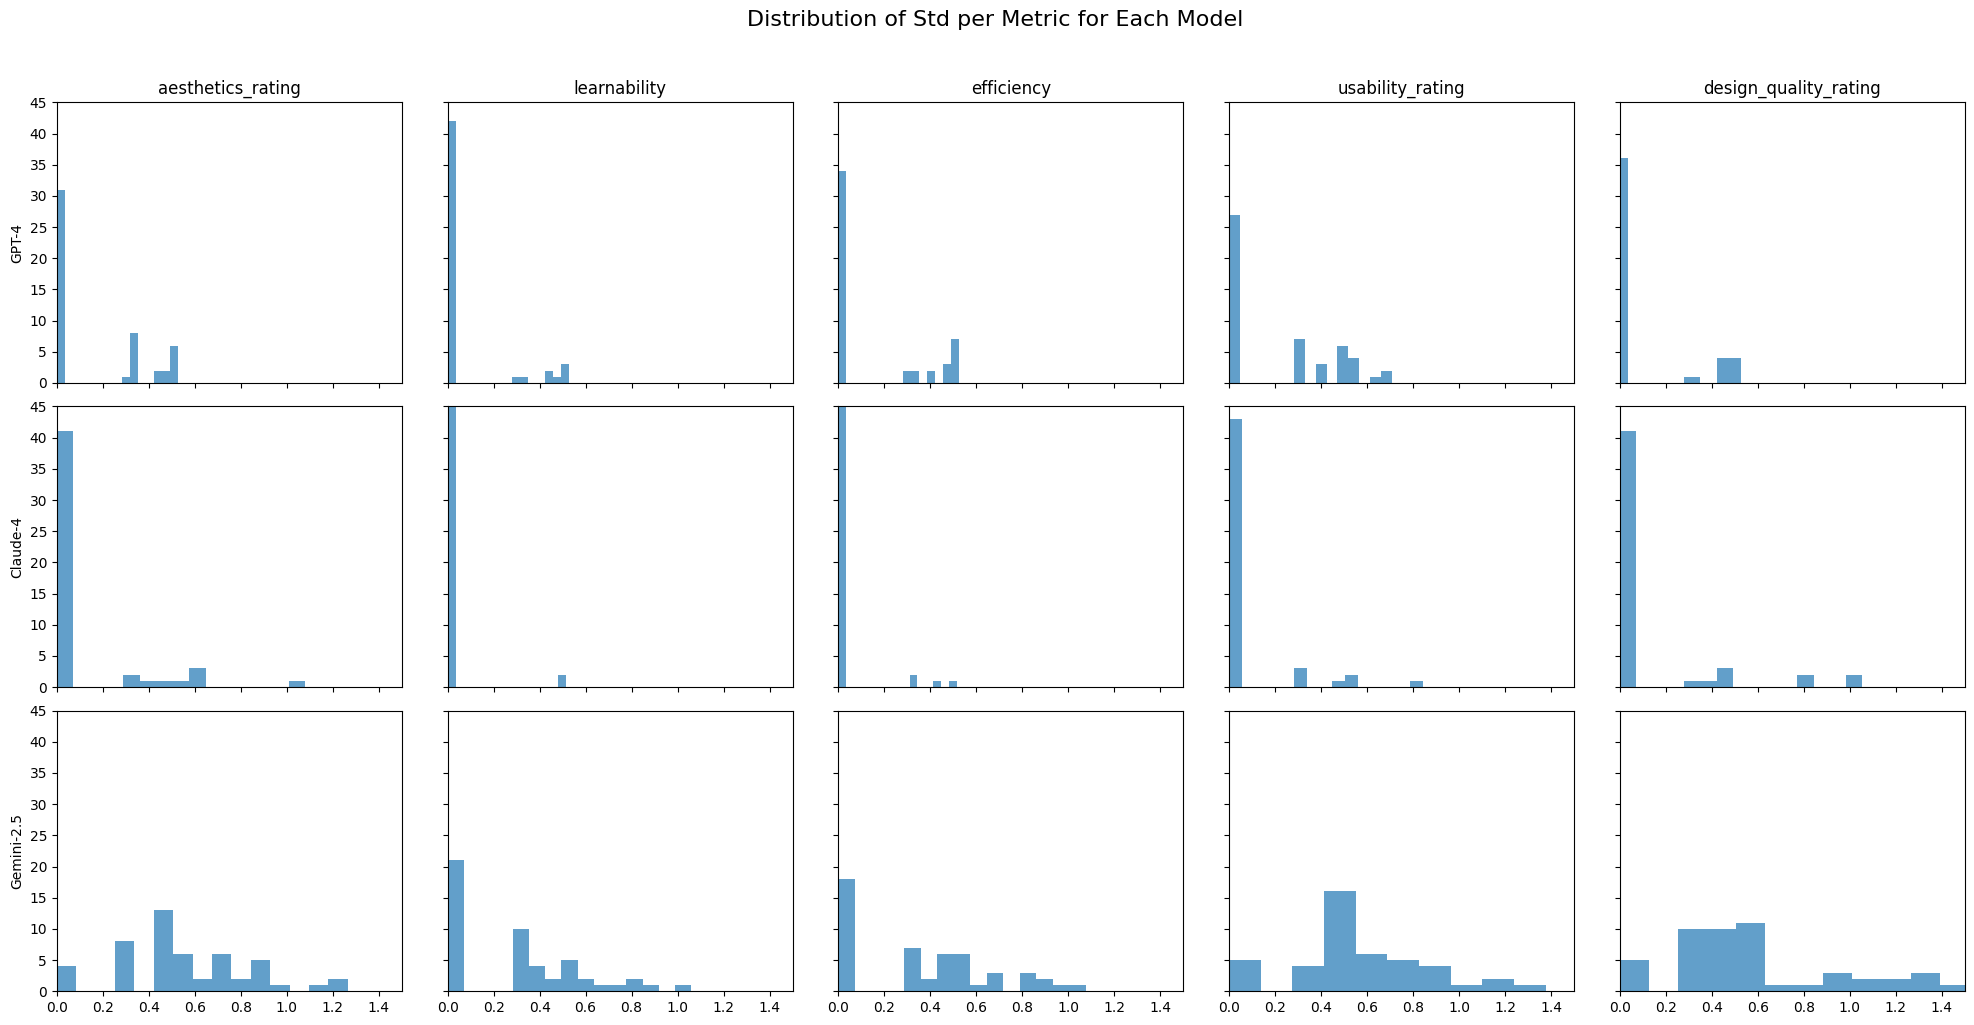

In [19]:
# Boxplot: Compare models per metric
plt.figure(figsize=(10, 6))
sns.boxplot(data=all_std_long, x='metric', y='std', hue='model')
plt.title('LLM Rating Variability (Std) per Metric (All Models)')
plt.ylabel('Standard Deviation')
plt.xlabel('Metric')
plt.ylim(0, 1.5)
plt.xticks(rotation=30)
plt.legend(title='Model')
plt.show()

# Histograms: Facet by metric, color by model
models = [
    ('GPT-4', gpt_std_long),
    ('Claude-4', claude_std_long),
    ('Gemini-2.5', gemini_std_long)
]
metrics = gpt_std_long['metric'].unique()

fig, axes = plt.subplots(nrows=3, ncols=5, figsize=(20, 10), sharex=True, sharey=True)

for row, (model_name, std_long) in enumerate(models):
    for col, metric in enumerate(metrics):
        ax = axes[row, col]
        data = std_long[std_long['metric'] == metric]['std']
        ax.hist(data, bins=15, color='C0', alpha=0.7)
        if row == 0:
            ax.set_title(metric)
        if col == 0:
            ax.set_ylabel(model_name)
        ax.set_xlim(0, 1.5)
        ax.set_ylim(0, 45)

fig.suptitle('Distribution of Std per Metric for Each Model', y=1.02, fontsize=16)
plt.tight_layout()
plt.show()

### Flags

In [22]:
# Flag top 10% inconsistent screens for each metric
std_long = gpt_std_long

flags = {}
for metric in std_long['metric'].unique():
    metric_df = std_long[std_long['metric'] == metric]
    threshold = metric_df['std'].quantile(0.9)
    flagged = metric_df[metric_df['std'] > threshold][['screen_task_id', 'std']]
    flags[metric] = flagged

for metric, df_flag in flags.items():
    print(f"\n=== {metric.upper()} ===")
    display(df_flag.sort_values('std', ascending=False))


=== AESTHETICS_RATING ===


,screen_task_id,std
24,1622_T01,0.527046
0,15_T01,0.516398
41,2783_T01,0.516398
49,3361_T01,0.516398



=== LEARNABILITY ===


,screen_task_id,std
96,3109_T01,0.527046
68,1138_T01,0.516398
82,2168_T01,0.516398
57,342_T01,0.483046



=== EFFICIENCY ===


,screen_task_id,std
145,3087_T01,0.527046
135,2257_T01,0.527046
146,3109_T01,0.527046
142,2879_T01,0.516398



=== USABILITY_RATING ===


,screen_task_id,std
192,2879_T01,0.707107
157,342_T01,0.699206
152,67_T01,0.632456
196,3109_T01,0.527046
185,2257_T01,0.527046



=== DESIGN_QUALITY_RATING ===


,screen_task_id,std
219,1245_T01,0.527046
223,1574_T01,0.527046
235,2257_T01,0.527046
232,2168_T01,0.516398


##############################


## EDA

#### Boxplot: Expert vs All LLM Models

In [ ]:
def plot_expert_vs_models(model_dfs, metrics, title="Expert vs LLM Ratings per Metric"):
    """
    Create boxplots comparing expert ratings with LLM model ratings for given metrics.

    Parameters
    ----------
    model_dfs : dict
        Dictionary mapping model name -> merged dataframe 
        (must contain expert ratings in `metric` and LLM ratings in `f"{metric}_llm"`).
        Example: {"GPT-4": merged_gpt_df, "Claude-4": merged_claude_df}
    metrics : list
        List of metric names (strings).
    title : str, optional
        Title of the plot.
    """
    # Prepare long-form dataframe
    plot_data = []
    for model_name, df in model_dfs.items():
        for metric in metrics:
            if metric not in df or f"{metric}_llm" not in df:
                continue
            # Expert ratings
            plot_data.append(pd.DataFrame({
                "metric": metric,
                "rating": df[metric],
                "source": "Expert"
            }))
            # LLM ratings
            plot_data.append(pd.DataFrame({
                "metric": metric,
                "rating": df[f"{metric}_llm"],
                "source": model_name
            }))

    plot_long = pd.concat(plot_data, ignore_index=True)
    plot_long["metric"] = pd.Categorical(plot_long["metric"], categories=metrics, ordered=True)

    # Colors: red for experts, blue for all models
    color_map = {"Expert": "#f97171"}
    for model in model_dfs.keys():
        color_map[model] = "#69b3fd"

    plt.figure(figsize=(12, 6))
    sns.boxplot(
        data=plot_long,
        x="metric",
        y="rating",
        hue="source",
        palette=color_map
    )
    plt.title(title)
    plt.ylabel("Rating")
    plt.xlabel("Metric")
    # limit y-axis to 0-11
    plt.ylim(0, 11)
    plt.legend(title="Source")
    plt.tight_layout()
    plt.show()


In [ ]:
for metric in EVALUATION_FIVE_ASPECTS:
    print(f"Testing normality for metric: {metric}")
    test_normality(experts_df_filtered[metric].to_numpy())
    print()

Testing normality for metric: aesthetics_rating
4.414857774366787e-25 Shapiro-Wilk Test: Data does not look normally distributed (reject H0)
0.0 Kolmogorov-Smirnov Test: Data does not look normally distributed (reject H0)

Testing normality for metric: learnability
8.580794625556235e-35 Shapiro-Wilk Test: Data does not look normally distributed (reject H0)
0.0 Kolmogorov-Smirnov Test: Data does not look normally distributed (reject H0)

Testing normality for metric: efficiency
1.943292389059315e-33 Shapiro-Wilk Test: Data does not look normally distributed (reject H0)
0.0 Kolmogorov-Smirnov Test: Data does not look normally distributed (reject H0)

Testing normality for metric: usability_rating
1.6787260780540905e-24 Shapiro-Wilk Test: Data does not look normally distributed (reject H0)
0.0 Kolmogorov-Smirnov Test: Data does not look normally distributed (reject H0)

Testing normality for metric: design_quality_rating
2.1169848876813836e-25 Shapiro-Wilk Test: Data does not look normall

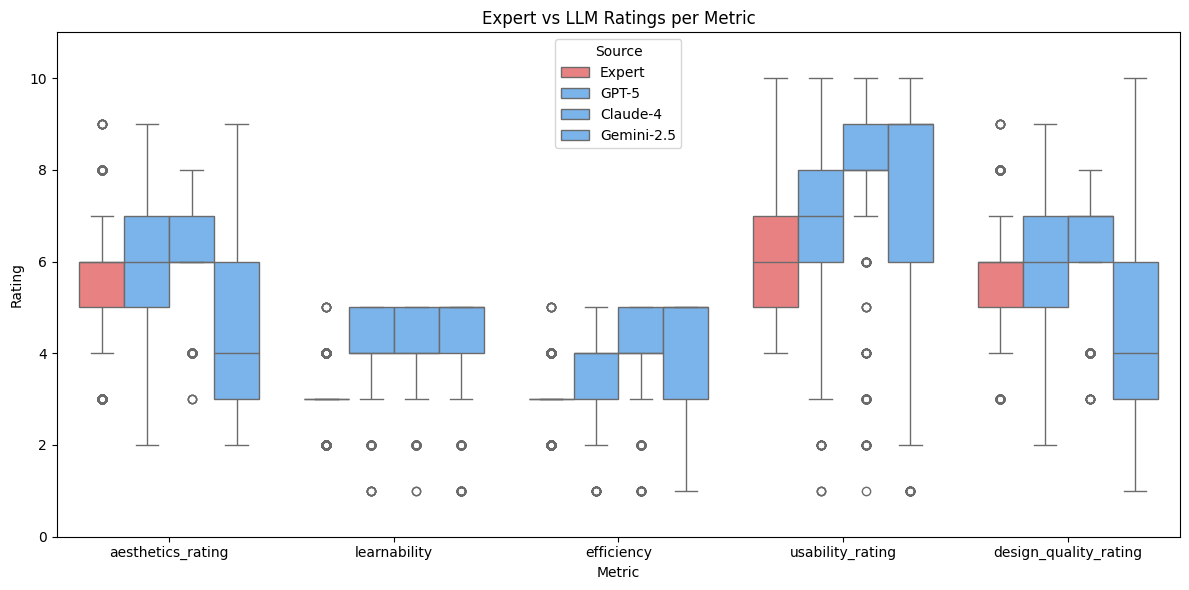

In [ ]:
plot_expert_vs_models(model_dfs_zs, EVALUATION_FIVE_ASPECTS)

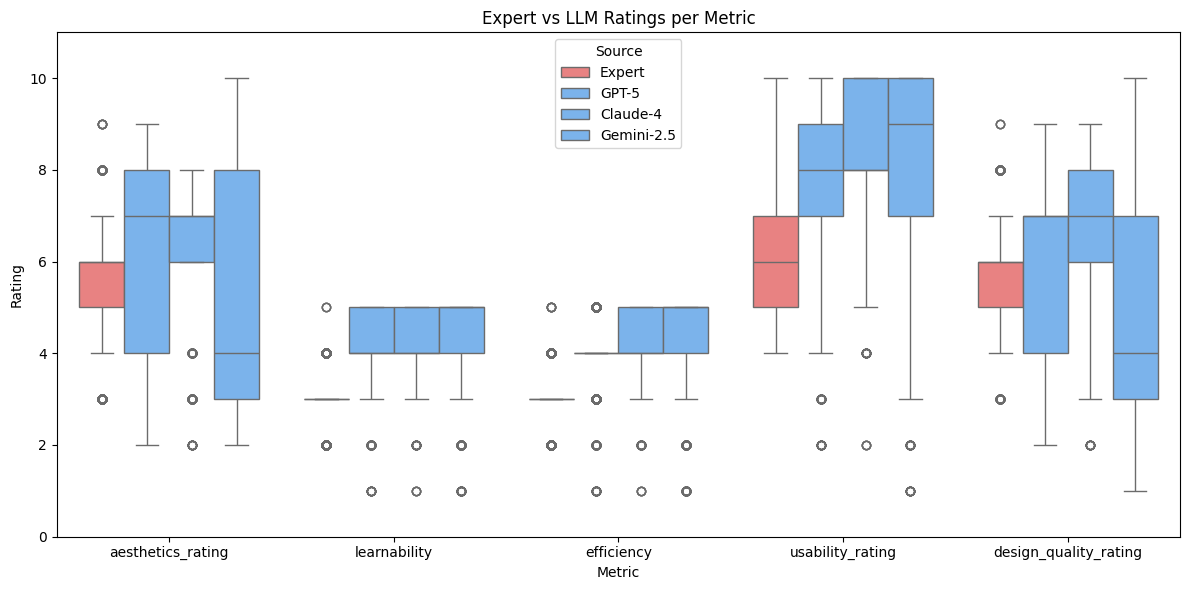

In [ ]:
plot_expert_vs_models(model_dfs_fs, EVALUATION_FIVE_ASPECTS)

## Compare LLMs to Experts

In [ ]:
# def normalize_series(series):
#     min_val = series.min()
#     max_val = series.max()
#     return (series - min_val) / (max_val - min_val) if max_val != min_val else series

def compute_stats_for_metric(df, metric, common_idx, categories, weights_type='quadratic'):
    llm_col = f"{metric}_llm"
    human_col = metric

    if llm_col not in df or human_col not in df:
        return {'Metric': metric, **{k: None for k in metric_headers()}}

    # Drop missing values and align
    df_valid = df[[common_idx, llm_col, human_col]].dropna()
    llm_vals = df_valid[llm_col]
    human_vals = df_valid[human_col]

    if llm_vals.empty or human_vals.empty:
        print(f"No valid data for metric {metric}")
        return {'Metric': metric, **{k: None for k in metric_headers()}}

    rmse = root_mean_squared_error(human_vals, llm_vals)
    icc = compute_icc(df_valid, common_idx)
    icc3 = icc.loc[icc['Type'] == 'ICC3', 'ICC'].values[0]
    t_stat, t_p = ttest_rel(human_vals, llm_vals)
    w_stat, w_p = wilcoxon(human_vals, llm_vals) if len(human_vals) >= 2 else (None, None)
    bp = bp_kappa_manually_defined(human_vals.round(0), llm_vals.round(0), labels=categories, weights_type=weights_type)
    
    return {
        'Metric': metric,
        'RMSE': round(rmse, 3),
        'ICC3': round(icc3, 3),
        'BP_Kappa': round(bp, 3) if bp is not None else None,
        'Ttest_t': round(t_stat, 3),
        'Ttest_p': round(t_p, 4),
        'Wilcoxon_stat': round(w_stat, 3) if w_stat is not None else None,
        'Wilcoxon_p': round(w_p, 4) if w_p is not None else None
    }

def metric_headers():
    return [
        'RMSE', 'ICC3', 'BP_Kappa',
        'Ttest_t', 'Ttest_p',
        'Wilcoxon_stat', 'Wilcoxon_p'
    ]

def evaluate_metric_agreement(df, metrics, common_idx, weights_type='quadratic'):
    # Drop rows with any NaNs in required columns
    all_columns = [f"{m}_llm" for m in metrics] + metrics
    df = df.dropna(subset=all_columns)

    results = [
        compute_stats_for_metric(df, metric, common_idx, CATEGORIES_DICT.get(metric, []), weights_type)
        for metric in metrics
    ]
    
    return pd.DataFrame(results)

In [8]:
# def build_stats_pivot(model_dfs, merged_gpt_df, merged_claude_df, merged_gemini_df, metrics, compute_stats):
def build_stats_pivot(model_dfs, metrics, compute_stats, common_idx='screen_task_id'):
    all_stats_list = []

    for model_name, df in model_dfs.items():
        stats_df = compute_stats(df, metrics, common_idx=common_idx)
        stats_df['Model'] = model_name
        all_stats_list.append(stats_df)

    all_stats = pd.concat(all_stats_list, ignore_index=True)

    # Keep only desired columns
    cols_to_keep = ['Model', 'Metric', 'ICC3', 'RMSE', 'BP_Kappa',
                    'Ttest_t', 'Ttest_p', 'Wilcoxon_stat', 'Wilcoxon_p']
    cols_to_keep = [c for c in cols_to_keep if c in all_stats.columns]
    all_stats = all_stats[cols_to_keep]

    # Long → Wide (pivot)
    stats_long = all_stats.melt(
        id_vars=['Model', 'Metric'],
        var_name='Stat',
        value_name='Value'
    )

    stats_pivot = stats_long.pivot_table(
        index=['Model', 'Stat'],
        columns='Metric',
        values='Value'
    )

    # Reorder columns
    stats_pivot = stats_pivot[metrics]

    return stats_pivot

def build_manova_pivot(model_dfs, metrics, compute_manova):
    # Compute MANOVA for each model
    results_list = []
    for model_name in model_dfs:
        manova_res = compute_manova(model_dfs[model_name], metrics)
        
        # Extract Wilks’ Lambda, Pillai, Hotelling-Lawley, Roy's largest root
        # manova_res.mv_test() returns a dict of tables; extract first table
        table = manova_res.results['source']['stat']
        # Create a row per model with statistics
        row = {
            'Model': model_name,
            'Wilks_Lambda': table.loc["Wilks' lambda", 'Value'],
            'Wilks_F': table.loc["Wilks' lambda", 'F Value'],
            'Wilks_p': table.loc["Wilks' lambda", 'Pr > F']
        }
        results_list.append(row)
    
    df_pivot = pd.DataFrame(results_list)
    return df_pivot


In [ ]:
stats_pivot_zs = build_stats_pivot(model_dfs_zs, EVALUATION_FIVE_ASPECTS, evaluate_metric_agreement)
manova_zs = build_manova_pivot(model_dfs_zs, EVALUATION_FIVE_ASPECTS, compute_manova)

display(stats_pivot_zs)
display(manova_zs)

NameError: name 'model_dfs_zs' is not defined

In [ ]:
stats_pivot_fs = build_stats_pivot(model_dfs_fs, EVALUATION_FIVE_ASPECTS, evaluate_metric_agreement)
manova_fs = build_manova_pivot(model_dfs_fs, EVALUATION_FIVE_ASPECTS, compute_manova)

display(stats_pivot_fs)
display(manova_fs)

Metric                    aesthetics_rating  learnability  efficiency  \
Model      Stat                                                         
Claude-4   BP_Kappa                  0.8020         0.352       0.410   
           ICC3                      0.1030         0.097       0.067   
           RMSE                      1.8080         1.610       1.536   
           Ttest_p                   0.0000         0.000       0.000   
           Ttest_t                 -10.6630       -51.252     -42.240   
           Wilcoxon_p                0.0000         0.000       0.000   
           Wilcoxon_stat         89857.0000      7487.000   13605.500   
GPT-5      BP_Kappa                  0.7570         0.387       0.566   
           ICC3                      0.1490         0.084       0.108   
           RMSE                      2.0020         1.565       1.317   
           Ttest_p                   0.0001         0.000       0.000   
           Ttest_t                  -3.9840       -36.971     -25.594   
           Wilcoxon_p                0.0002         0.000       0.000   
           Wilcoxon_stat        139211.0000     18601.000   36030.000   
Gemini-2.5 BP_Kappa                  0.6180         0.130       0.218   
           ICC3                      0.1410         0.069       0.042   
           RMSE                      2.5090         1.866       1.769   
           Ttest_p                   0.0000         0.000       0.000   
           Ttest_t                   9.3550       -37.430     -27.605   
           Wilcoxon_p                0.0000         0.000       0.000   
           Wilcoxon_stat        128628.5000     25454.500   46546.500   

Metric                    usability_rating  design_quality_rating  
Model      Stat                                                    
Claude-4   BP_Kappa                  0.400                 0.7960  
           ICC3                      0.107                 0.1100  
           RMSE                      3.146                 1.8350  
           Ttest_p                   0.000                 0.0000  
           Ttest_t                 -54.562               -14.5540  
           Wilcoxon_p                0.000                 0.0000  
           Wilcoxon_stat          9289.500             81744.5000  
GPT-5      BP_Kappa                  0.571                 0.7860  
           ICC3                      0.101                 0.1520  
           RMSE                      2.662                 1.8800  
           Ttest_p                   0.000                 0.0007  
           Ttest_t                 -30.492                -3.3870  
           Wilcoxon_p                0.000                 0.0010  
           Wilcoxon_stat         40101.500            135851.0000  
Gemini-2.5 BP_Kappa                  0.350                 0.5990  
           ICC3                      0.065                 0.1350  
           RMSE                      3.275                 2.5730  
           Ttest_p                   0.000                 0.0000  
           Ttest_t                 -26.549                10.2870  
           Wilcoxon_p                0.000                 0.0000  
           Wilcoxon_stat         58420.000            123279.0000

,Model,Wilks_Lambda,Wilks_F,Wilks_p
0,GPT-5,0.505327,389.216903,1.847848e-291
1,Claude-4,0.374553,663.932250,0.000000e+00
2,Gemini-2.5,0.481056,428.914438,1.120224e-312


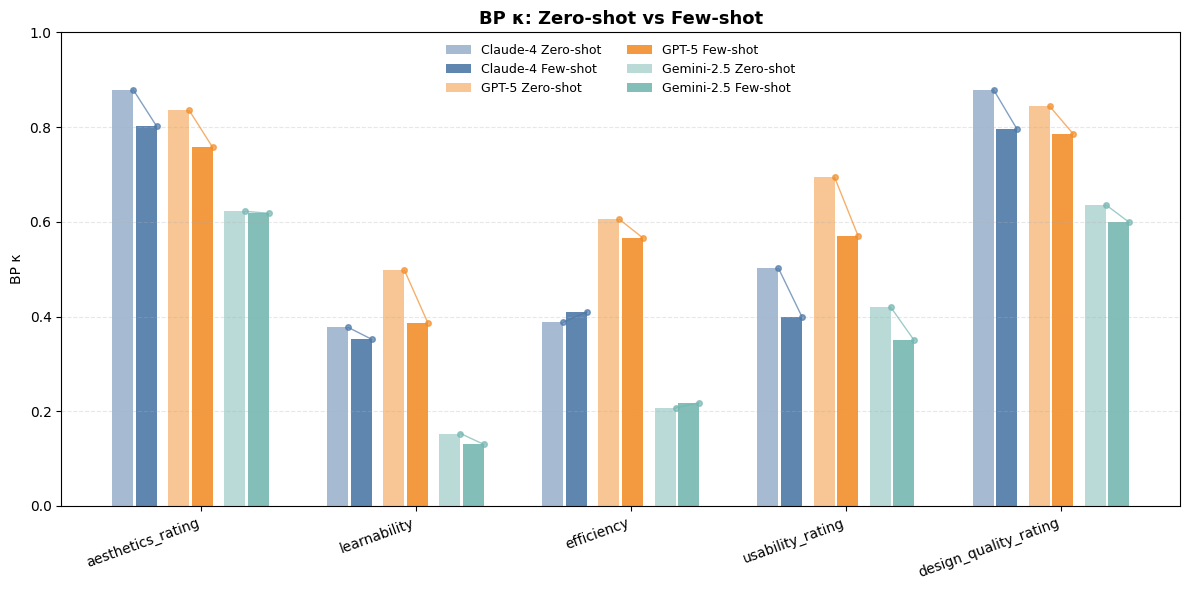

In [ ]:
def plot_hybrid_kappa(stats_pivot_zs, stats_pivot_fs, title="BP κ: Zero-shot vs Few-shot"):
    """
    Hybrid plot: paired bars for zero-shot & few-shot with a connector line
    for each (model, metric). Uses consistent softer colors per model.
    """
    # Select BP_Kappa rows
    df_zs = stats_pivot_zs.xs('BP_Kappa', level='Stat')
    df_fs = stats_pivot_fs.xs('BP_Kappa', level='Stat')

    models = list(df_zs.index)
    metrics = list(df_zs.columns)

    # Softer, colorblind-friendly palette
    model_colors = {
        "Claude-4": "#4E79A7",   # muted blue
        "GPT-5": "#F28E2B",     # soft orange
        "Gemini-2.5": "#76B7B2" # teal
    }

    bar_width = 0.18
    gap_within_model = 0.02
    gap_between_models = 0.10
    gap_between_metrics = 0.50

    per_model_block = 2 * bar_width + gap_within_model
    per_metric_block = len(models) * per_model_block + (len(models) - 1) * gap_between_models

    metric_centers = []
    x_positions_zs, x_positions_fs = {}, {}

    for mi, metric in enumerate(metrics):
        base = mi * (per_metric_block + gap_between_metrics)
        cursor = base
        for mj, model in enumerate(models):
            x_zs = cursor
            x_fs = cursor + bar_width + gap_within_model
            x_positions_zs[(model, metric)] = x_zs
            x_positions_fs[(model, metric)] = x_fs
            cursor += per_model_block + gap_between_models
        metric_centers.append(base + per_metric_block / 2.0)

    fig, ax = plt.subplots(figsize=(12, 6))

    for model in models:
        zs_heights = [df_zs.loc[model, m] for m in metrics]
        fs_heights = [df_fs.loc[model, m] for m in metrics]
        zs_x = [x_positions_zs[(model, m)] for m in metrics]
        fs_x = [x_positions_fs[(model, m)] for m in metrics]
        color = model_colors[model]

        # Bars (softer alpha for ZS, solid for FS)
        ax.bar(zs_x, zs_heights, width=bar_width, color=color, alpha=0.5, label=f"{model} Zero-shot")
        ax.bar(fs_x, fs_heights, width=bar_width, color=color, alpha=0.9, label=f"{model} Few-shot")

        # Connectors (thin + desaturated)
        for x1, y1, x2, y2 in zip(zs_x, zs_heights, fs_x, fs_heights):
            cx1 = x1 + bar_width / 2.0
            cx2 = x2 + bar_width / 2.0
            ax.plot([cx1, cx2], [y1, y2], marker='o', markersize=4,
                    color=color, alpha=0.7, linewidth=1)

    # Labels & style
    ax.set_title(title, fontsize=13, weight="bold")
    ax.set_ylabel("BP κ")
    ax.set_xticks(metric_centers)
    ax.set_xticklabels(metrics, rotation=20, ha='right')
    ax.set_ylim(0, 1.0)
    ax.grid(axis='y', linestyle='--', alpha=0.3)

    # Legend deduplication
    handles, labels = ax.get_legend_handles_labels()
    by_label = dict(zip(labels, handles))
    ax.legend(by_label.values(), by_label.keys(), ncol=2, frameon=False, fontsize=9)

    plt.tight_layout()
    plt.show()


plot_hybrid_kappa(stats_pivot_zs, stats_pivot_fs)


### Visualizations

In [38]:
def summarize_significance(stats_pivot_zs, stats_pivot_fs, metrics, test="Wilcoxon", alpha=0.05):
    """
    Summarize significance results (Wilcoxon or T-test) for Zero-shot vs Few-shot.

    Parameters
    ----------
    stats_pivot_zs : pd.DataFrame
        Pivot table for zero-shot stats (Model × Stat × Metric).
    stats_pivot_fs : pd.DataFrame
        Pivot table for few-shot stats.
    metrics : list
        List of metric names (columns in stats_pivot).
    test : str, optional
        Which test to summarize ("Wilcoxon" or "Ttest").
    alpha : float, optional
        Significance threshold (default = 0.05).

    Returns
    -------
    df_long : pd.DataFrame
        Long-format summary of p-values and significance flags.
    """

    # Map test name to stat key
    test_map = {
        "Wilcoxon": "Wilcoxon_p",
        "Ttest": "Ttest_p"
    }
    if test not in test_map:
        raise ValueError(f"test must be one of {list(test_map.keys())}")

    stat_key = test_map[test]

    # Extract from ZS and FS
    zs = stats_pivot_zs.loc[pd.IndexSlice[:, stat_key], metrics].reset_index()
    zs["Setting"] = "Zero-shot"

    fs = stats_pivot_fs.loc[pd.IndexSlice[:, stat_key], metrics].reset_index()
    fs["Setting"] = "Few-shot"

    # Merge
    merged = pd.concat([zs, fs], ignore_index=True)

    # Long format
    df_long = merged.melt(
        id_vars=["Model", "Stat", "Setting"],
        var_name="Metric",
        value_name="p_value"
    )

    # Mark significance
    df_long["Significant"] = df_long["p_value"].apply(
        lambda p: "Yes" if p is not None and p < alpha else "No"
    )

    return df_long


def plot_significance_heatmap(df_long, test="Wilcoxon", alpha=0.05):
    """
    Plot a heatmap of significance results.
    """
    plt.figure(figsize=(10, 6))
    pivoted = df_long.pivot_table(
        index=["Model", "Setting"], columns="Metric", values="Significant", aggfunc="first"
    ).replace({"Yes": 1, "No": 0})

    sns.heatmap(
        pivoted,
        annot=True,
        cmap="coolwarm",
        cbar=False,
        linewidths=0.5
    )
    plt.title(f"{test} Test Significance (p < {alpha})")
    plt.show()


C:\Users\mahmo\AppData\Local\Temp\ipykernel_20256\2198308677.py:66: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({"Yes": 1, "No": 0})


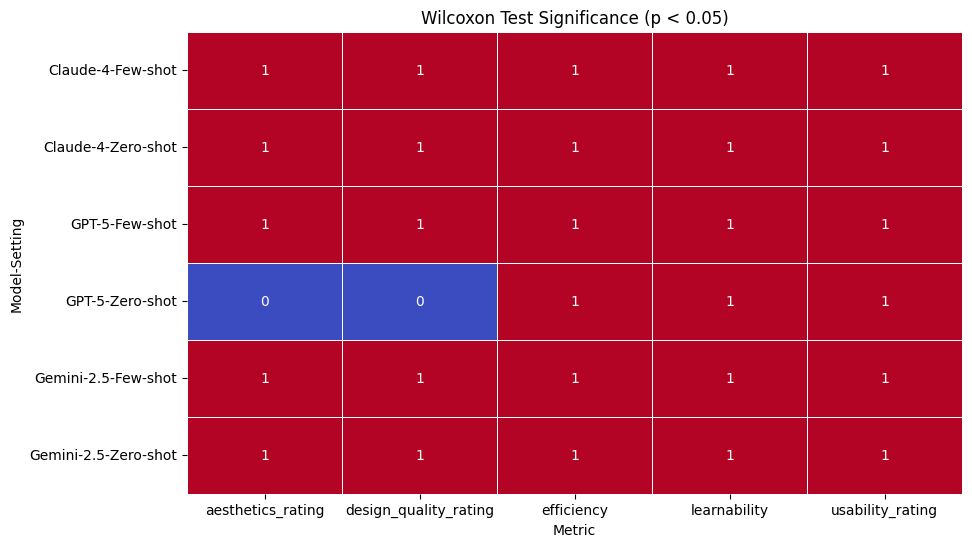

C:\Users\mahmo\AppData\Local\Temp\ipykernel_20256\2198308677.py:66: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ).replace({"Yes": 1, "No": 0})


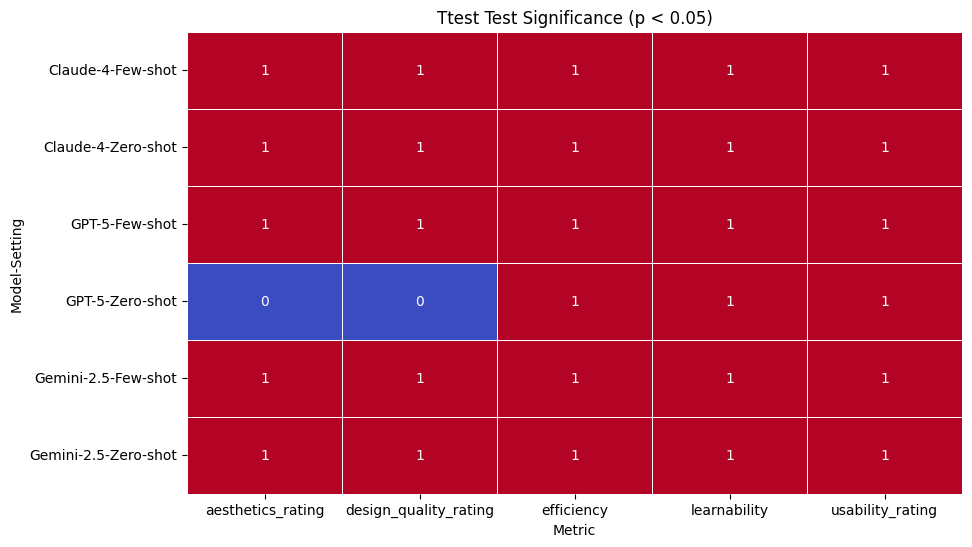

In [ ]:
alpha = 0.05

# Summarize Wilcoxon results
wilcoxon_summary = summarize_significance(stats_pivot_zs, stats_pivot_fs, EVALUATION_FIVE_ASPECTS, test="Wilcoxon", alpha=alpha)
plot_significance_heatmap(wilcoxon_summary, test="Wilcoxon", alpha=alpha)

# Summarize T-test results
ttest_summary = summarize_significance(stats_pivot_zs, stats_pivot_fs, EVALUATION_FIVE_ASPECTS, test="Ttest", alpha=alpha)
plot_significance_heatmap(ttest_summary, test="Ttest", alpha=alpha)


In [11]:
def compute_effect_size(model_dfs, metrics):
    """
    Compute effect size (Cohen's d) and optional rank-biserial correlation
    between Expert and LLM ratings for each metric & model.

    Parameters
    ----------
    model_dfs : dict
        Dictionary of model_name -> merged dataframe
    metrics : list
        List of metric names

    Returns
    -------
    df_effects : pd.DataFrame
        Columns: Model, Metric, Cohen_d, RankBiserial (optional)
    """
    results = []

    for model_name, df in model_dfs.items():
        for metric in metrics:
            if metric not in df or f"{metric}_llm" not in df:
                continue
            expert = df[metric].dropna()
            llm = df[f"{metric}_llm"].dropna()
            common_idx = expert.index.intersection(llm.index)
            expert_vals = expert.loc[common_idx]
            llm_vals = llm.loc[common_idx]
            if len(expert_vals) < 2:
                continue

            # Paired Cohen's d
            diff = llm_vals - expert_vals
            cohen_d = diff.mean() / diff.std(ddof=1)

            # Rank-biserial correlation from Wilcoxon
            try:
                w_stat, w_p = wilcoxon(expert_vals, llm_vals)
                n = len(diff)
                rank_biserial = 1 - (2 * w_stat) / (n*(n+1)/2)
            except:
                rank_biserial = np.nan

            results.append({
                "Model": model_name,
                "Metric": metric,
                "Cohen_d": round(cohen_d, 2),
                "RankBiserial": round(rank_biserial, 2)
            })

    return pd.DataFrame(results)

def pivot_effect_size_multiindex(effects_df):
    """
    Convert effect size DataFrame to pivot table with MultiIndex like stats_pivot.
    Index = (Model, Stat), Columns = Metrics, Values = effect size

    Parameters
    ----------
    effects_df : pd.DataFrame
        Must have columns ["Model", "Metric", "Cohen_d", "RankBiserial"]

    Returns
    -------
    pd.DataFrame
        Pivot table with MultiIndex (Model, Stat) and metrics as columns
    """
    # Melt so each effect size type becomes a row
    effects_long = effects_df.melt(
        id_vars=["Model", "Metric"],
        value_vars=["Cohen_d", "RankBiserial"],
        var_name="Stat",
        value_name="Value"
    )

    # Pivot to get MultiIndex
    effects_pivot = effects_long.pivot_table(
        index=["Model", "Stat"],
        columns="Metric",
        values="Value"
    )

    return effects_pivot

In [ ]:
effects_df = compute_effect_size(model_dfs_zs, EVALUATION_FIVE_ASPECTS)

effects_df.pivot_table(index='Model', columns='Metric', values=['Cohen_d', 'RankBiserial'])

Cohen_d  ...     RankBiserial
Metric     aesthetics_rating  ... usability_rating
Model                         ...                 
Claude-4                0.37  ...             0.80
GPT-5                   0.05  ...             0.72
Gemini-2.5             -0.72  ...             0.66

[3 rows x 10 columns]

In [ ]:
effects_df = compute_effect_size(model_dfs_fs, EVALUATION_FIVE_ASPECTS)

effects_df.pivot_table(index='Model', columns='Metric', values=['Cohen_d', 'RankBiserial'])

Cohen_d  ...     RankBiserial
Metric     aesthetics_rating  ... usability_rating
Model                         ...                 
Claude-4                0.34  ...             0.96
GPT-5                   0.13  ...             0.84
Gemini-2.5             -0.30  ...             0.77

[3 rows x 10 columns]

### MANOVA (combine the 5 metrics)

## Compare LLMs to each other

In [ ]:
from itertools import combinations

def compute_bp_kappa_table(model_dfs, metrics):
    results = {}

    model_names = list(model_dfs.keys())
    for metric in metrics:
        kappa_matrix = pd.DataFrame(
            index=model_names, columns=model_names, dtype=float
        )

        # fill diagonal with 1 (perfect agreement with itself)
        for m in model_names:
            kappa_matrix.loc[m, m] = 1.0

        # compute pairwise kappa
        for m1, m2 in combinations(model_names, 2):
            df1 = model_dfs[m1][f"{metric}_llm"].dropna()
            df2 = model_dfs[m2][f"{metric}_llm"].dropna()
            common_idx = df1.index.intersection(df2.index)
            if len(common_idx) == 0:
                kappa = None
            else:
                r1 = df1.loc[common_idx]
                r2 = df2.loc[common_idx]
                kappa = bp_kappa_manually_defined(r1, r2, labels=CATEGORIES_DICT.get(metric))

            kappa_matrix.loc[m1, m2] = kappa
            kappa_matrix.loc[m2, m1] = kappa

        results[metric] = kappa_matrix

    return results

def upper_triangle_bp_results(bp_results, keep_diagonal=True):
    results_upper = {}
    for metric, df in bp_results.items():
        mask = np.triu(np.ones(df.shape), k=0 if keep_diagonal else 1).astype(bool)
        df_upper = df.where(mask)  # keep only upper triangle
        results_upper[metric] = df_upper
    return results_upper


In [52]:
def plot_bp_kappa_heatmaps(bp_results, cmap="Blues"):
    for metric, kappa_matrix in bp_results.items():
        plt.figure(figsize=(4, 3))
        sns.heatmap(kappa_matrix, annot=True, cmap=cmap, vmin=0, vmax=1, cbar=True)
        plt.title(f"Brennan-Prediger Kappa: {metric}")
        plt.ylabel("Model")
        plt.xlabel("Model")
        plt.tight_layout()
        plt.show()

def plot_bp_kappa_bars(bp_results):
    plot_data = []
    for metric, df in bp_results.items():
        for m1, m2 in combinations(df.index, 2):
            plot_data.append({
                "Metric": metric,
                "Pair": f"{m1} vs {m2}",
                "Kappa": df.loc[m1, m2]
            })
    plot_df = pd.DataFrame(plot_data)

    plt.figure(figsize=(10,6))
    sns.barplot(
        data=plot_df, 
        x="Metric", 
        y="Kappa", 
        hue="Pair"
    )
    plt.ylim(0, 1)
    plt.title("Brennan-Prediger Kappa Agreement Between Models")
    plt.ylabel("BP Kappa")
    plt.show()


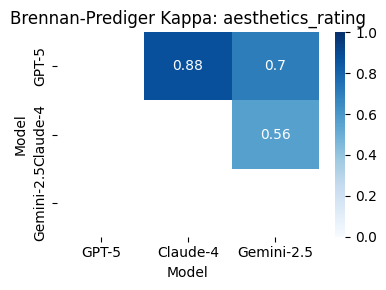

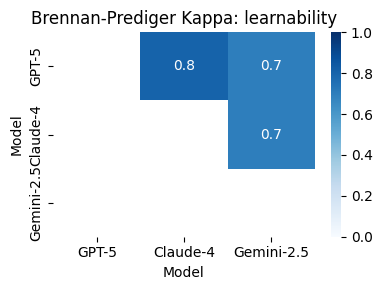

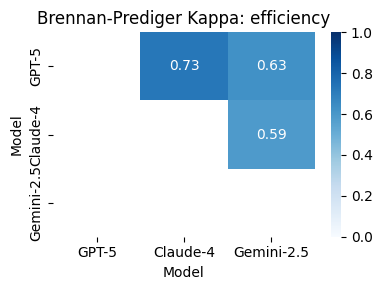

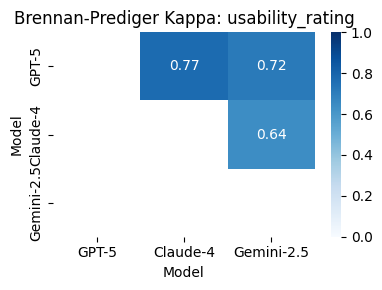

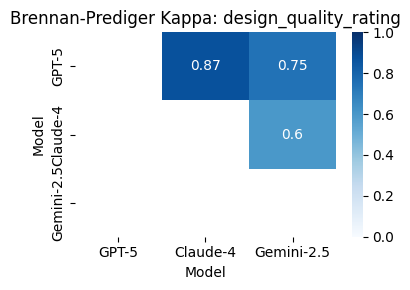

In [ ]:
bp_results = compute_bp_kappa_table(model_dfs_zs, EVALUATION_FIVE_ASPECTS)
bp_results_upper = upper_triangle_bp_results(bp_results, keep_diagonal=False)

plot_bp_kappa_heatmaps(bp_results_upper)  # your plotting function


In [ ]:
# divide the experts ratings in each metric into 3 bins: low, medium, high
# then compute bp_kappa for each bin
def bin_expert_ratings(experts_df_filtered, metrics):
    binned = {}
    for metric in metrics:
        if metric not in experts_df_filtered:
            continue
        if metric in ['learnability', 'efficiency']:
            bins = [0, 2, 4, 5]  # 1-2: low, 3-4: medium, 5: high
            labels = ['Low', 'Medium', 'High']
        else:
            bins = [0, 3, 7, 10]  # 1-3: low, 4-7: medium, 8-10: high
            labels = ['Low', 'Medium', 'High']
        binned[metric] = pd.cut(experts_df_filtered[metric], bins=bins, labels=labels, include_lowest=True)
    return pd.DataFrame(binned)
binned_experts = bin_expert_ratings(experts_df_filtered, EVALUATION_FIVE_ASPECTS)
binned_experts['screen_task_id'] = experts_df_filtered['screen_task_id']


In [ ]:
# for the same bins, did any of the models rated out of the bin range? how many?


# Store Results